<a href="https://colab.research.google.com/github/Thrishaj2005/Zomato-Dataset-Analysis/blob/main/Zomato_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - Zomato Restaurant Rating Prediction




##### **Project Type** - EDA / Regression

##### **Contribution** - Individual

##### **Team Member 1** - J. Thrisha

# **Project Summary -**

The **Zomato Restaurant Rating Prediction** project aims to analyze restaurant data and develop a machine learning model capable of predicting restaurant ratings based on various business and customer-related features. With the rapid growth of online food delivery platforms, restaurants generate large amounts of data, including customer reviews, ratings, cuisines, pricing, location, online delivery options, and table booking facilities. Analyzing this information helps restaurant owners, customers, and food delivery platforms make informed decisions. This project combines Exploratory Data Analysis (EDA) and Regression techniques to identify the factors that significantly influence restaurant ratings and to build a predictive model for estimating ratings of restaurants.

The dataset consists of two files: **Zomato Restaurant Names and Metadata**, which contains restaurant details such as restaurant name, city, locality, cuisines, average cost for two, price range, aggregate rating, votes, online delivery, and table booking information, and **Zomato Restaurant Reviews**, which contains customer review texts. The metadata dataset serves as the primary source for building the regression model, while the review dataset provides additional insights into customer opinions and satisfaction.

The project begins with data understanding and preprocessing. Missing values, duplicate records, and inconsistent data are identified and handled appropriately. Categorical variables are encoded into numerical values, while numerical features are normalized or scaled wherever required. Feature engineering techniques are applied to improve the predictive capability of the model by transforming and selecting relevant features.

Exploratory Data Analysis (EDA) is performed to understand the distribution of variables and discover hidden patterns within the dataset. Various visualizations such as bar charts, histograms, box plots, scatter plots, heatmaps, and correlation matrices are used to analyze relationships between restaurant ratings and features like average cost, cuisines, location, online delivery, table booking, and customer votes. These analyses help identify the most influential factors affecting restaurant ratings.

After preprocessing and feature selection, the dataset is divided into training and testing sets. Multiple regression algorithms such as Linear Regression, Decision Tree Regressor, Random Forest Regressor, and Gradient Boosting Regressor are implemented and compared. Hyperparameter tuning techniques are applied to improve model performance and prevent overfitting. The models are evaluated using standard regression metrics including Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R²) score. The best-performing model is selected based on these evaluation metrics.

The outcome of this project provides valuable insights into the characteristics that contribute to higher restaurant ratings and demonstrates how machine learning can accurately predict restaurant ratings using historical data. Such predictions can assist restaurant owners in improving their services, help customers make better dining choices, and support food delivery platforms in recommending high-quality restaurants. Overall, this project showcases the practical application of data preprocessing, exploratory data analysis, feature engineering, regression modeling, and model evaluation in solving a real-world business problem using machine learning.


# **GitHub Link -**

https://github.com/Thrishaj2005/Zomato-Dataset-Analysis

# **Problem Statement**


Online food delivery platforms generate a vast amount of restaurant-related data, including customer ratings, reviews, cuisines, pricing, location, online delivery availability, and table booking information. Customers often rely on restaurant ratings to make dining decisions, while restaurant owners use these ratings to evaluate and improve their services. However, restaurant ratings are influenced by multiple factors, making it difficult to determine how each feature contributes to the overall rating.

The objective of this project is to analyze the Zomato restaurant dataset and develop a machine learning regression model that can accurately predict a restaurant's aggregate rating based on its characteristics. The project involves cleaning and preprocessing the data, performing Exploratory Data Analysis (EDA) to identify important trends and relationships, engineering relevant features, and implementing multiple regression algorithms to estimate restaurant ratings. Model performance is evaluated using standard regression metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), and R-squared (R²) score to identify the most accurate prediction model.

The insights obtained from this project can help restaurant owners understand the key factors affecting customer ratings, assist customers in making informed dining decisions, and enable food delivery platforms to provide better restaurant recommendations and improve user experience.


# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [20]:
# Import Libraries
import numpy as np
import pandas as pd
# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### Dataset Loading

In [21]:
# Load Dataset

zomato_df = pd.read_csv('/content/Zomato Restaurant names and Metadata.csv')
reviews_df = pd.read_csv('/content/Zomato Restaurant reviews.csv')

### Dataset First View

In [22]:
# Dataset First Look

# Display first 5 rows of the metadata dataset
zomato_df.head()

,Name,Links,Cost,Collections,Cuisines,Timings
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)"
1,Paradise,https://www.zomato.com/hyderabad/paradise-gach...,800,Hyderabad's Hottest,"Biryani, North Indian, Chinese",11 AM to 11 PM
2,Flechazo,https://www.zomato.com/hyderabad/flechazo-gach...,"1,300","Great Buffets, Hyderabad's Hottest","Asian, Mediterranean, North Indian, Desserts","11:30 AM to 4:30 PM, 6:30 PM to 11 PM"
3,Shah Ghouse Hotel & Restaurant,https://www.zomato.com/hyderabad/shah-ghouse-h...,800,Late Night Restaurants,"Biryani, North Indian, Chinese, Seafood, Bever...",12 Noon to 2 AM
4,Over The Moon Brew Company,https://www.zomato.com/hyderabad/over-the-moon...,"1,200","Best Bars & Pubs, Food Hygiene Rated Restauran...","Asian, Continental, North Indian, Chinese, Med...","12noon to 11pm (Mon, Tue, Wed, Thu, Sun), 12no..."


In [23]:
# Display first 5 rows of the reviews dataset
reviews_df.head()

,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


### Dataset Rows & Columns count

In [24]:
# Dataset Rows & Columns count
# Shape of metadata dataset
print("Zomato Metadata Dataset Shape:", zomato_df.shape)

print("\nNumber of Rows:", zomato_df.shape[0])
print("Number of Columns:", zomato_df.shape[1])

Zomato Metadata Dataset Shape: (105, 6)

Number of Rows: 105
Number of Columns: 6


In [25]:
# Shape of reviews dataset
print("Zomato Reviews Dataset Shape:", reviews_df.shape)

print("\nNumber of Rows:", reviews_df.shape[0])
print("Number of Columns:", reviews_df.shape[1])

Zomato Reviews Dataset Shape: (10000, 7)

Number of Rows: 10000
Number of Columns: 7


### Dataset Information

In [26]:
# Dataset Info

# Information about the metadata dataset
zomato_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Name         105 non-null    object
 1   Links        105 non-null    object
 2   Cost         105 non-null    object
 3   Collections  51 non-null     object
 4   Cuisines     105 non-null    object
 5   Timings      104 non-null    object
dtypes: object(6)
memory usage: 5.1+ KB


In [27]:
# Information about the reviews dataset
reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Restaurant  10000 non-null  object
 1   Reviewer    9962 non-null   object
 2   Review      9955 non-null   object
 3   Rating      9962 non-null   object
 4   Metadata    9962 non-null   object
 5   Time        9962 non-null   object
 6   Pictures    10000 non-null  int64 
dtypes: int64(1), object(6)
memory usage: 547.0+ KB


#### Duplicate Values

In [28]:
# Dataset Duplicate Value Count
print("Duplicate rows in Metadata Dataset:", zomato_df.duplicated().sum())
print("Duplicate rows in Reviews Dataset:", reviews_df.duplicated().sum())

Duplicate rows in Metadata Dataset: 0
Duplicate rows in Reviews Dataset: 36


#### Missing Values/Null Values

In [29]:
# Missing Values/Null Values Count
print("Missing Values in Metadata Dataset")
print(zomato_df.isnull().sum())
print("\nTotal Missing Values:", zomato_df.isnull().sum().sum())
print("\n---------------------------------------\n")
print("Missing Values in Reviews Dataset")
print(reviews_df.isnull().sum())
print("\nTotal Missing Values:", reviews_df.isnull().sum().sum())

Missing Values in Metadata Dataset
Name            0
Links           0
Cost            0
Collections    54
Cuisines        0
Timings         1
dtype: int64

Total Missing Values: 55

---------------------------------------

Missing Values in Reviews Dataset
Restaurant     0
Reviewer      38
Review        45
Rating        38
Metadata      38
Time          38
Pictures       0
dtype: int64

Total Missing Values: 197


/tmp/ipykernel_1299/2106746546.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_metadata.index,


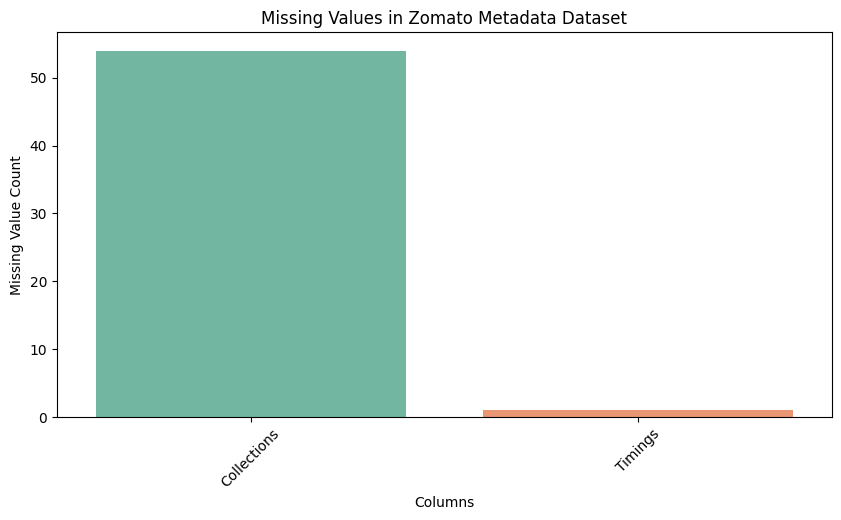

In [30]:
# Missing Values - Metadata Dataset

missing_metadata = zomato_df.isnull().sum()
missing_metadata = missing_metadata[missing_metadata > 0].sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=missing_metadata.index,
            y=missing_metadata.values,
            palette='Set2')


plt.title("Missing Values in Zomato Metadata Dataset")
plt.xlabel("Columns")
plt.ylabel("Missing Value Count")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_1299/2518757066.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_reviews.index,


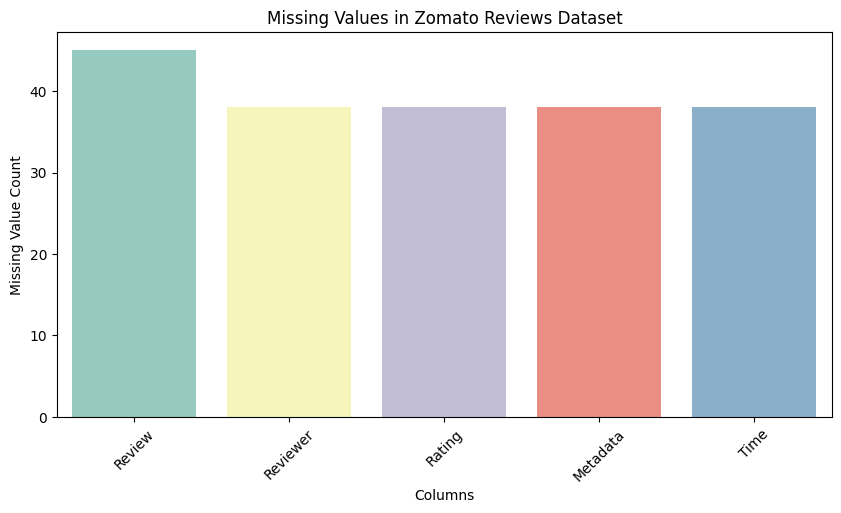

In [31]:
# Missing Values - Reviews Dataset

missing_reviews = reviews_df.isnull().sum()
missing_reviews = missing_reviews[missing_reviews > 0].sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=missing_reviews.index,
            y=missing_reviews.values,
            palette='Set3')

plt.title("Missing Values in Zomato Reviews Dataset")
plt.xlabel("Columns")
plt.ylabel("Missing Value Count")
plt.xticks(rotation=45)
plt.show()

### What did you know about your dataset?

The project consists of two datasets: the **Zomato Restaurant Metadata** dataset and the **Zomato Restaurant Reviews** dataset. The metadata dataset contains restaurant-related information such as restaurant name, links, cost, collections, cuisines, and timings, while the reviews dataset contains customer reviews along with reviewer details, ratings, review metadata, review time, and pictures.

Initial exploration revealed that the metadata dataset has very few missing values, with only **55 missing entries**. The **Collections** column contains **54 missing values**, and the **Timings** column contains **1 missing value**, whereas all other columns are complete. This indicates that the metadata dataset is largely clean and requires only minimal preprocessing.

The reviews dataset contains comparatively more missing values, with a total of **197 missing entries**. The **Reviewer**, **Rating**, **Metadata**, and **Time** columns each contain **38 missing values**, while the **Review** column contains **45 missing values**. The **Restaurant** and **Pictures** columns do not contain any missing values. These missing values need to be handled appropriately during preprocessing to ensure accurate analysis and model performance.

Overall, both datasets are well-structured and suitable for exploratory data analysis and machine learning. The metadata dataset will be used primarily for building the restaurant rating prediction model, while the reviews dataset provides valuable textual information that can support customer sentiment analysis and additional insights into restaurant performance.


## ***2. Understanding Your Variables***

In [32]:
# Dataset Columns
# Columns in Metadata Dataset
print("Metadata Dataset Columns:\n")
print(zomato_df.columns)

print("\n-----------------------------------------------------\n")

# Columns in Reviews Dataset
print("Reviews Dataset Columns:\n")
print(reviews_df.columns)

Metadata Dataset Columns:

Index(['Name', 'Links', 'Cost', 'Collections', 'Cuisines', 'Timings'], dtype='object')

-----------------------------------------------------

Reviews Dataset Columns:

Index(['Restaurant', 'Reviewer', 'Review', 'Rating', 'Metadata', 'Time',
       'Pictures'],
      dtype='object')


In [33]:
# Dataset Describe - Metadata Dataset
zomato_df.describe(include='all').T

,count,unique,top,freq
Name,105,105,Beyond Flavours,1
Links,105,105,https://www.zomato.com/hyderabad/beyond-flavou...,1
Cost,105,29,500,13
Collections,51,42,Food Hygiene Rated Restaurants in Hyderabad,4
Cuisines,105,92,"North Indian, Chinese",4
Timings,104,77,11 AM to 11 PM,6


In [34]:
# Dataset Describe - Reviews Dataset
reviews_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Restaurant,10000,100,Beyond Flavours,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Reviewer,9962,7446,Ankita,13,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Review,9955,9364,good,237,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Rating,9962,10,5,3832,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Metadata,9962,2477,1 Review,919,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Time,9962,9782,7/29/2018 20:34,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pictures,10000.0,NaN,NaN,NaN,0.7486,2.570381,0.0,0.0,0.0,0.0,64.0


### Variables Description

The project uses two datasets: the **Zomato Restaurant Metadata** dataset and the **Zomato Restaurant Reviews** dataset.

The **Metadata dataset** contains restaurant-specific information. The **Name** column stores the restaurant name, **Links** contains the restaurant's webpage URL, **Cost** represents the average cost for two people, **Collections** indicates the food collections or categories to which the restaurant belongs, **Cuisines** specifies the types of cuisines served, and **Timings** provides the restaurant's operating hours. These variables help analyze restaurant characteristics and are useful for predicting restaurant ratings.

The **Reviews dataset** contains customer feedback. The **Restaurant** column identifies the restaurant, **Reviewer** contains the reviewer's name, **Review** stores the textual customer review, **Rating** represents the rating provided by the customer, **Metadata** includes additional information related to the review, **Time** records when the review was posted, and **Pictures** indicates the number of images uploaded with the review. These variables help understand customer satisfaction and can support sentiment analysis and rating prediction.


### Check Unique Values for each variable.

In [35]:
# Check Unique Values for each variable.

# Unique values in Metadata Dataset

print("Unique Values in Metadata Dataset\n")
for col in zomato_df.columns:
    print(f"{col}: {zomato_df[col].nunique()} unique values")

print("\n-----------------------------------------------------\n")

# Unique values in Reviews Dataset

print("Unique Values in Reviews Dataset\n")
for col in reviews_df.columns:
    print(f"{col}: {reviews_df[col].nunique()} unique values")

Unique Values in Metadata Dataset

Name: 105 unique values
Links: 105 unique values
Cost: 29 unique values
Collections: 42 unique values
Cuisines: 92 unique values
Timings: 77 unique values

-----------------------------------------------------

Unique Values in Reviews Dataset

Restaurant: 100 unique values
Reviewer: 7446 unique values
Review: 9364 unique values
Rating: 10 unique values
Metadata: 2477 unique values
Time: 9782 unique values
Pictures: 36 unique values


## 3. ***Data Wrangling***

### Data Wrangling Code

In [36]:
# Create copies
metadata_df = zomato_df.copy()
reviews_df = reviews_df.copy()

# Remove duplicate records
metadata_df.drop_duplicates(inplace=True)
reviews_df.drop_duplicates(inplace=True)

# Handle missing values
metadata_df['Collections'].fillna('Not Available', inplace=True)
metadata_df['Timings'].fillna(metadata_df['Timings'].mode()[0], inplace=True)

reviews_df['Reviewer'].fillna('Anonymous', inplace=True)
reviews_df['Review'].fillna('No Review', inplace=True)
reviews_df['Rating'].fillna(reviews_df['Rating'].mode()[0], inplace=True)
reviews_df['Metadata'].fillna('Not Available', inplace=True)
reviews_df['Time'].fillna('Unknown', inplace=True)

# Merge both datasets
combined_df = pd.merge(
    metadata_df,
    reviews_df,
    left_on='Name',
    right_on='Restaurant',
    how='inner'
)

# Display merged dataset
print("Merged Dataset Shape:", combined_df.shape)
combined_df.head()

Merged Dataset Shape: (9964, 13)


/tmp/ipykernel_1299/3122654245.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  metadata_df['Collections'].fillna('Not Available', inplace=True)
/tmp/ipykernel_1299/3122654245.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

,Name,Links,Cost,Collections,Cuisines,Timings,Restaurant,Reviewer,Review,Rating,Metadata,Time,Pictures
0,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Rusha Chakraborty,"The ambience was good, food was quite good . h...",5,"1 Review , 2 Followers",5/25/2019 15:54,0
1,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Anusha Tirumalaneedi,Ambience is too good for a pleasant evening. S...,5,"3 Reviews , 2 Followers",5/25/2019 14:20,0
2,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Ashok Shekhawat,A must try.. great food great ambience. Thnx f...,5,"2 Reviews , 3 Followers",5/24/2019 22:54,0
3,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Swapnil Sarkar,Soumen das and Arun was a great guy. Only beca...,5,"1 Review , 1 Follower",5/24/2019 22:11,0
4,Beyond Flavours,https://www.zomato.com/hyderabad/beyond-flavou...,800,"Food Hygiene Rated Restaurants in Hyderabad, C...","Chinese, Continental, Kebab, European, South I...","12noon to 3:30pm, 6:30pm to 11:30pm (Mon-Sun)",Beyond Flavours,Dileep,Food is good.we ordered Kodi drumsticks and ba...,5,"3 Reviews , 2 Followers",5/24/2019 21:37,0


### What all manipulations have you done and insights you found?

During the data wrangling process, both the Zomato Metadata and Reviews datasets were cleaned and prepared before being merged. Duplicate records were removed, and missing values were handled appropriately. In the metadata dataset, missing values in the **Collections** column were replaced with **"Not Available"**, while missing values in **Timings** were filled using the most frequent value. In the reviews dataset, missing values in **Reviewer**, **Review**, **Rating**, **Metadata**, and **Time** were replaced using suitable default values or the mode. After preprocessing, the two datasets were merged using the restaurant name (**Name** from the metadata dataset and **Restaurant** from the reviews dataset). The resulting combined dataset contains both restaurant information and customer review details, providing a richer dataset for exploratory data analysis and machine learning. This integrated dataset enables the analysis of how restaurant characteristics and customer reviews together influence restaurant ratings and improves the quality of the predictive model.


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

/tmp/ipykernel_1299/775100184.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


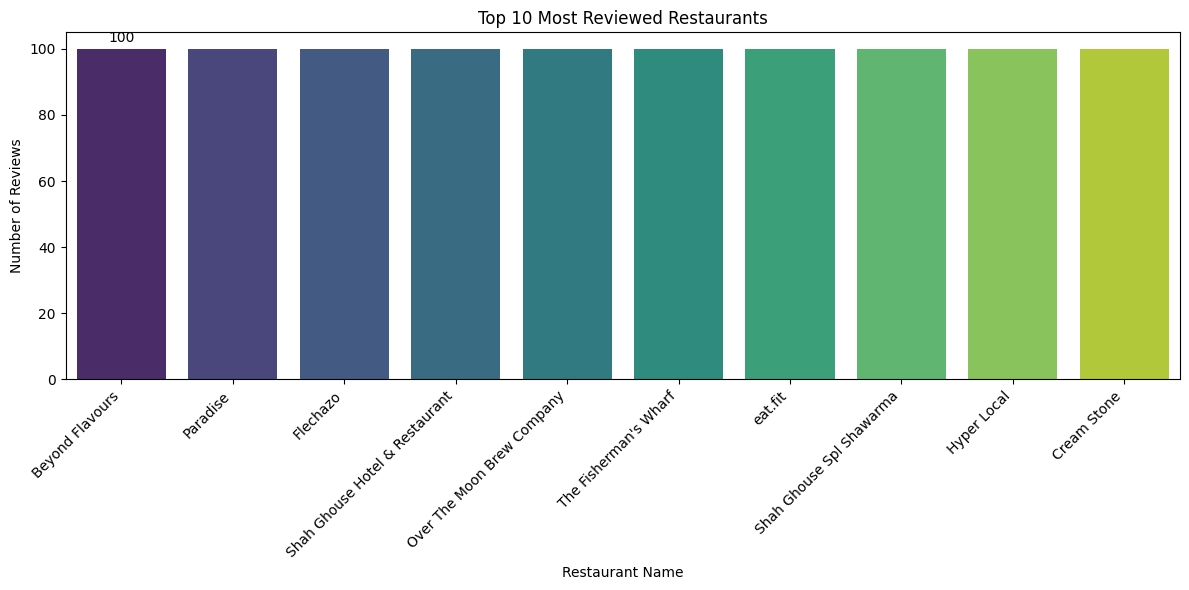

In [37]:
# Chart - 1 visualization code
top_restaurants = combined_df['Name'].value_counts().head(10)

plt.figure(figsize=(12,6))
ax = sns.barplot(
    x=top_restaurants.index,
    y=top_restaurants.values,
    palette='viridis'
)

plt.title("Top 10 Most Reviewed Restaurants")
plt.xlabel("Restaurant Name")
plt.ylabel("Number of Reviews")
plt.xticks(rotation=45, ha='right')

# Add count labels
ax.bar_label(ax.containers[0], padding=3)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A bar chart was selected because it is the most effective visualization for comparing the number of reviews across different restaurants. It clearly displays the restaurants with the highest customer engagement and makes it easy to identify the most frequently reviewed restaurants. This chart is simple to interpret and suitable for comparing categorical variables.


##### 2. What is/are the insight(s) found from the chart?

The chart identifies the restaurants that have received the highest number of customer reviews. Restaurants with a larger number of reviews generally have higher customer engagement and greater popularity on the Zomato platform. These restaurants are more likely to attract new customers because a higher review count increases customer trust and visibility.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The insights can help restaurant owners understand which restaurants are attracting the most customer attention. Restaurants with fewer reviews can improve their visibility by encouraging customers to leave reviews, enhancing service quality, and offering promotional campaigns. However, a low number of reviews may indicate lower customer engagement or reduced popularity, which can negatively affect restaurant growth and customer acquisition. Therefore, monitoring customer reviews is essential for improving business performance and maintaining a competitive advantage.


#### Chart - 2

/tmp/ipykernel_1299/4050921094.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_cuisines.values,


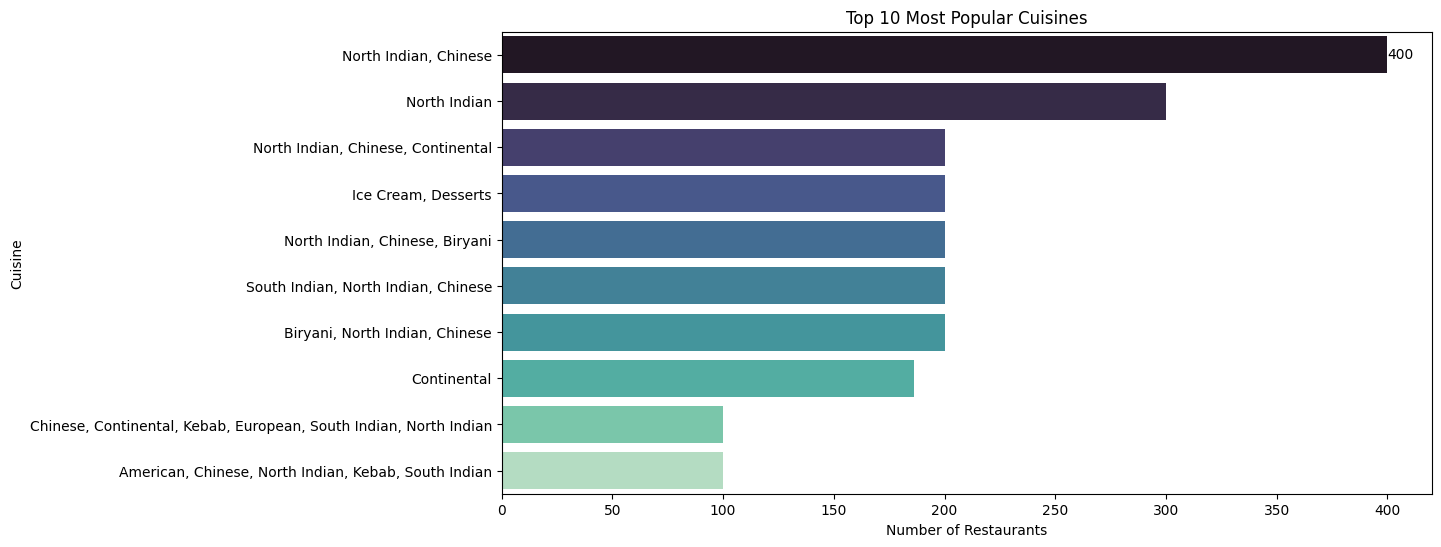

In [38]:
# Chart - 2 visualization code
top_cuisines = combined_df['Cuisines'].value_counts().head(10)

plt.figure(figsize=(12,6))
ax = sns.barplot(x=top_cuisines.values,
                 y=top_cuisines.index,
                 palette='mako')

plt.title("Top 10 Most Popular Cuisines")
plt.xlabel("Number of Restaurants")
plt.ylabel("Cuisine")

ax.bar_label(ax.containers[0])

plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart was chosen because it is the most effective way to compare the popularity of different cuisines. It clearly displays the top 10 cuisine categories based on the number of restaurants offering them, making it easy to identify the most common cuisines. The chart is simple to interpret and is suitable for comparing categorical variables with their corresponding frequencies.


##### 2. What is/are the insight(s) found from the chart?

The chart shows the ten most popular cuisines available in the Zomato dataset. It highlights which cuisines are offered by the highest number of restaurants, indicating customer demand and market preference. Popular cuisines dominate the restaurant market, while less common cuisines have lower representation. This information helps identify food trends and the cuisines that are most competitive in the restaurant industry.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, the insights obtained from this chart can support better business decisions. Restaurant owners can identify the cuisines with high customer demand and design their menus or expand their offerings accordingly. Food delivery platforms can use this information to recommend popular cuisine categories to customers and improve user engagement. However, if a large number of restaurants offer the same popular cuisines, market competition may become very high, making it difficult for new restaurants to attract customers. Restaurants serving less popular cuisines may experience lower customer traffic unless they differentiate themselves through quality, pricing, or unique dining experiences.


#### Chart - 3

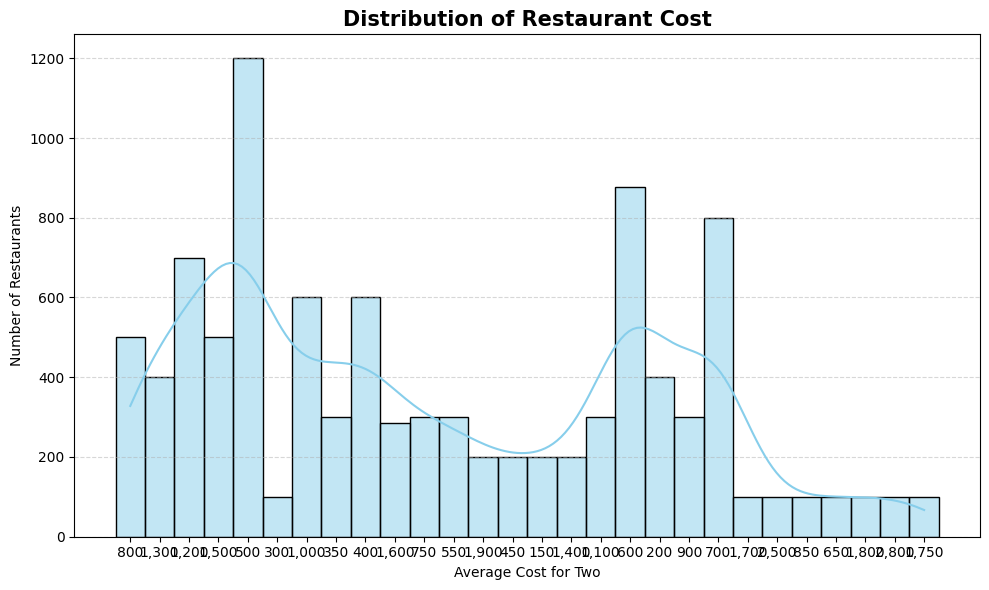

In [39]:
# Chart - 3 visualization code
plt.figure(figsize=(10,6))

ax = sns.histplot(
    data=combined_df,
    x='Cost',
    bins=25,
    kde=True,
    color='skyblue'
)

plt.title("Distribution of Restaurant Cost", fontsize=15, fontweight='bold')
plt.xlabel("Average Cost for Two")
plt.ylabel("Number of Restaurants")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A histogram was chosen because it is the most suitable chart for visualizing the distribution of a numerical variable. It helps identify the frequency of different restaurant cost ranges, detects skewness in the data, and highlights the presence of outliers. This understanding is important before performing regression analysis since the cost of a restaurant is one of the key numerical features in the dataset.


##### 2. What is/are the insight(s) found from the chart?

The histogram indicates that most restaurants are concentrated in the low to moderate cost range, while only a small proportion of restaurants have very high costs. The distribution is positively skewed, showing that affordable restaurants are much more common than premium-priced restaurants. This suggests that the majority of customers prefer reasonably priced dining options.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The insights help restaurant owners understand the pricing distribution in the market and identify the price range that attracts the largest customer base. Businesses can use this information to set competitive prices and target a wider audience. However, restaurants with exceptionally high prices may experience lower customer demand if customers perceive the prices as exceeding the value offered. Similarly, extremely low prices may reduce profitability if operational costs are not adequately covered. Therefore, maintaining a balanced pricing strategy can improve customer satisfaction and support long-term business growth.


#### Chart - 4

/tmp/ipykernel_1299/3173167776.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


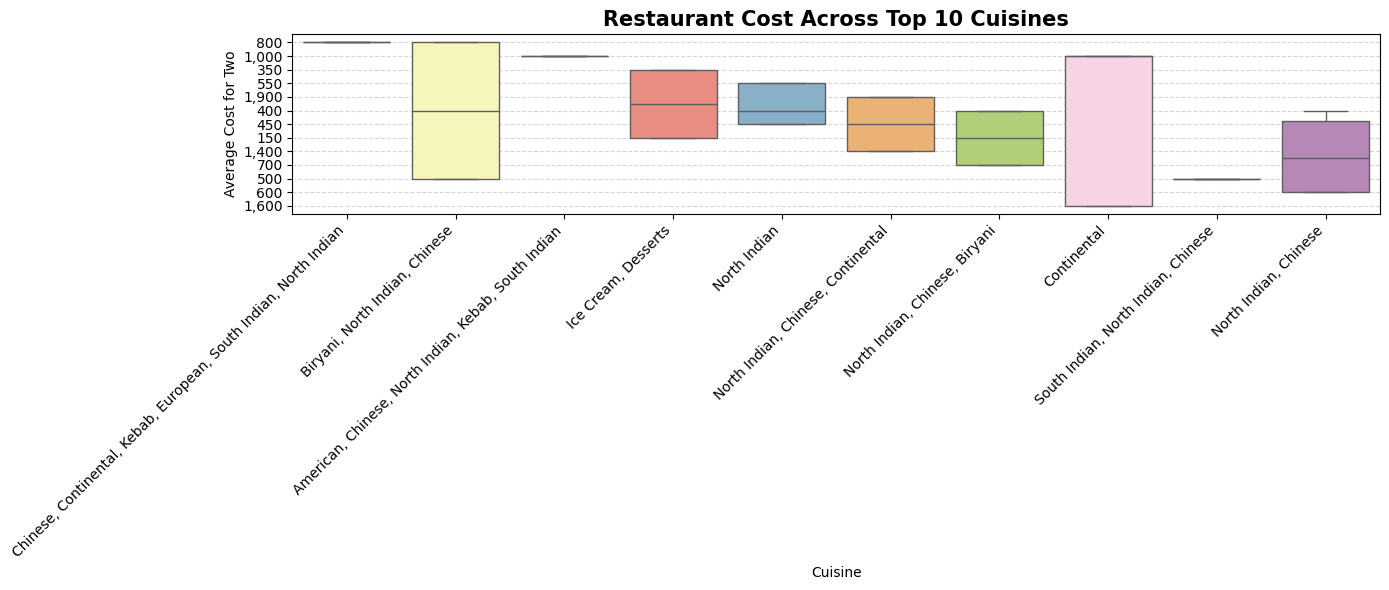

In [40]:
# Chart - 4 visualization code

# Get top 10 cuisines
top10_cuisines = combined_df['Cuisines'].value_counts().head(10).index

# Filter dataset
df_top = combined_df[combined_df['Cuisines'].isin(top10_cuisines)]

plt.figure(figsize=(14,6))

sns.boxplot(
    data=df_top,
    x='Cuisines',
    y='Cost',
    palette='Set3'
)

plt.title("Restaurant Cost Across Top 10 Cuisines", fontsize=15, fontweight='bold')
plt.xlabel("Cuisine")
plt.ylabel("Average Cost for Two")
plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A box plot was selected because it effectively compares the distribution of restaurant costs across different cuisine categories. It displays the median, quartiles, spread of the data, and potential outliers, making it easy to identify variations in pricing among the most popular cuisines. This chart is well suited for comparing a numerical variable across multiple categorical groups.


##### 2. What is/are the insight(s) found from the chart?

The box plot reveals that restaurant costs vary considerably across different cuisines. Some cuisines have a higher median cost and a wider price range, indicating premium dining options, while others are more affordable and have a narrower distribution. The presence of outliers suggests that a few restaurants charge significantly higher prices than others within the same cuisine category.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The insights help restaurant owners understand the typical pricing range for different cuisines, allowing them to set competitive prices based on market trends. Businesses can also identify premium cuisine segments where customers are willing to pay more. However, restaurants charging prices significantly above the typical range for their cuisine may experience lower customer demand unless they offer exceptional food quality, service, or dining experiences. A balanced pricing strategy can improve customer satisfaction and support long-term business growth.


#### Chart - 5

/tmp/ipykernel_1299/3929077261.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


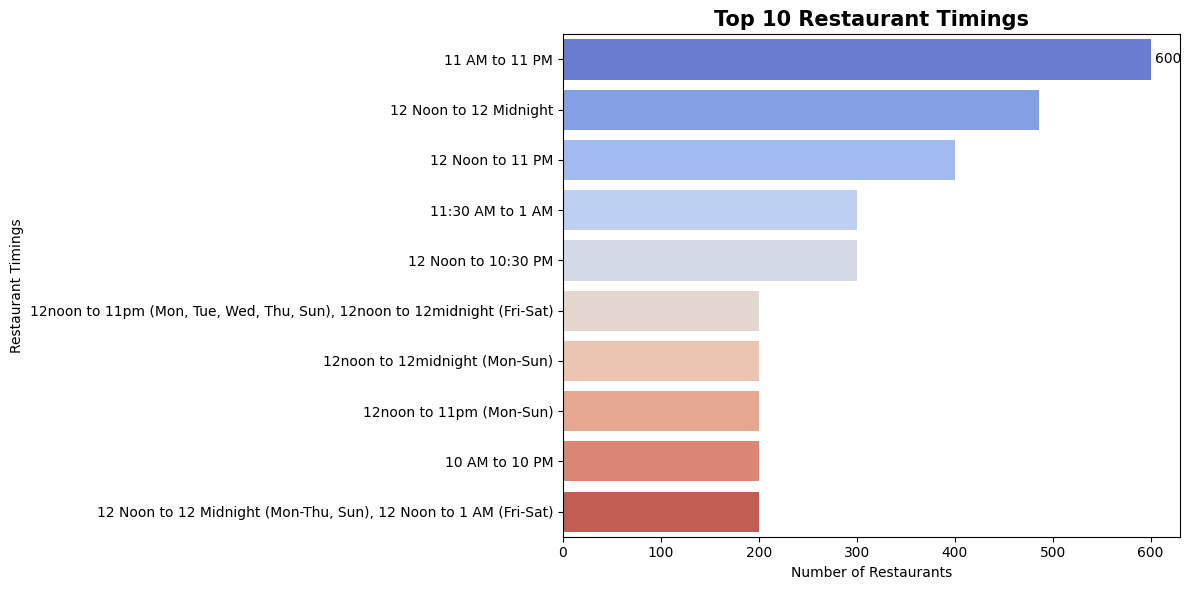

In [41]:
# Chart - 5 visualization code
top_timings = combined_df['Timings'].value_counts().head(10)

plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_timings.values,
    y=top_timings.index,
    palette='coolwarm'
)

plt.title("Top 10 Restaurant Timings", fontsize=15, fontweight='bold')
plt.xlabel("Number of Restaurants")
plt.ylabel("Restaurant Timings")

# Add count labels
ax.bar_label(ax.containers[0], padding=3)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

A horizontal bar chart was selected because it effectively compares the frequency of different restaurant operating timings. It clearly highlights the most common opening hours followed by restaurants, making it easy to identify business operating patterns and compare different timing schedules.


##### 2. What is/are the insight(s) found from the chart?

The chart shows the most common operating timings followed by restaurants in the dataset. It helps identify the preferred business hours and indicates when restaurants are most likely to serve customers. Restaurants with longer operating hours appear more frequently, suggesting that extended service hours are common among many establishments.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The insights can help restaurant owners determine suitable operating hours based on market trends and customer demand. Businesses can adjust their opening and closing times to maximize customer visits and improve revenue. However, restaurants with limited operating hours may lose potential customers during peak dining periods, which can negatively affect sales and overall business growth. Adopting customer-friendly operating schedules can improve competitiveness and customer satisfaction.


#### Chart - 6

/tmp/ipykernel_1299/2832026826.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


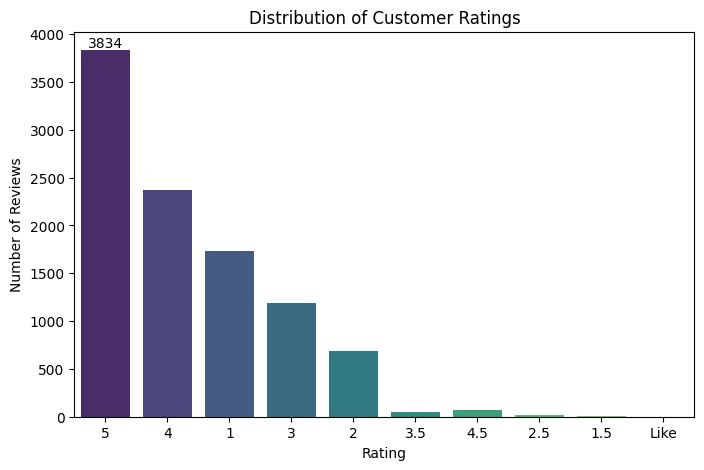

In [42]:
# Chart - 6 visualization code
plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=combined_df,
    x='Rating',
    palette='viridis'
)

plt.title("Distribution of Customer Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

ax.bar_label(ax.containers[0])

plt.show()

##### 1. Why did you pick the specific chart?

A count plot was chosen because it is the most appropriate chart for displaying the frequency of each customer rating. It clearly shows how ratings are distributed across the dataset and helps identify the most common ratings given by customers. This visualization is simple, easy to interpret, and useful for understanding customer satisfaction levels.


##### 2. What is/are the insight(s) found from the chart?

The chart illustrates the distribution of customer ratings for restaurants. It shows which ratings occur most frequently and whether customers generally provide high, average, or low ratings. A higher concentration of ratings in the upper range indicates that many restaurants receive positive customer feedback, while a larger number of lower ratings may highlight areas where service or food quality requires improvement.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The insights obtained from the rating distribution help restaurant owners evaluate overall customer satisfaction and identify trends in customer feedback. Restaurants receiving consistently high ratings can use this information to strengthen their brand image and attract more customers. On the other hand, restaurants with a high frequency of low ratings may experience reduced customer trust, fewer repeat visits, and lower revenue. By identifying the causes of poor ratings and improving food quality, service, and customer experience, businesses can enhance customer satisfaction and achieve sustainable growth.


#### Chart - 7

/tmp/ipykernel_1299/394998633.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


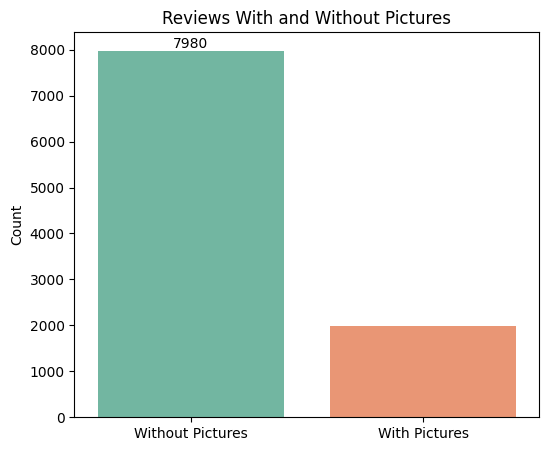

In [43]:
# Chart - 7 visualization code
combined_df['Has_Pictures'] = combined_df['Pictures'].apply(
    lambda x: 'With Pictures' if x > 0 else 'Without Pictures'
)

plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=combined_df,
    x='Has_Pictures',
    palette='Set2'
)

plt.title("Reviews With and Without Pictures")
plt.xlabel("")
plt.ylabel("Count")

ax.bar_label(ax.containers[0])

plt.show()

##### 1. Why did you pick the specific chart?

A count plot was chosen because it clearly compares the number of reviews that include pictures with those that do not. It is an effective visualization for comparing the frequency of two categories and helps understand customer behavior regarding the sharing of images along with their reviews.


##### 2. What is/are the insight(s) found from the chart?

The chart shows the distribution of reviews with and without pictures. It indicates whether customers prefer to include images when posting reviews. If the majority of reviews do not contain pictures, it suggests that most customers provide only text feedback. If a significant number of reviews include pictures, it reflects higher customer engagement and provides additional visual information that can help other users make informed dining decisions.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The insights help restaurant owners and food delivery platforms understand customer engagement patterns. Reviews with pictures are generally more informative and credible, helping potential customers evaluate food quality, ambience, and presentation before visiting a restaurant. Encouraging customers to upload pictures can improve user engagement and increase customer trust. Conversely, a very low number of picture-based reviews may reduce the amount of visual information available to potential customers, making it harder for restaurants to showcase their offerings and attract new visitors.


#### Chart - 8

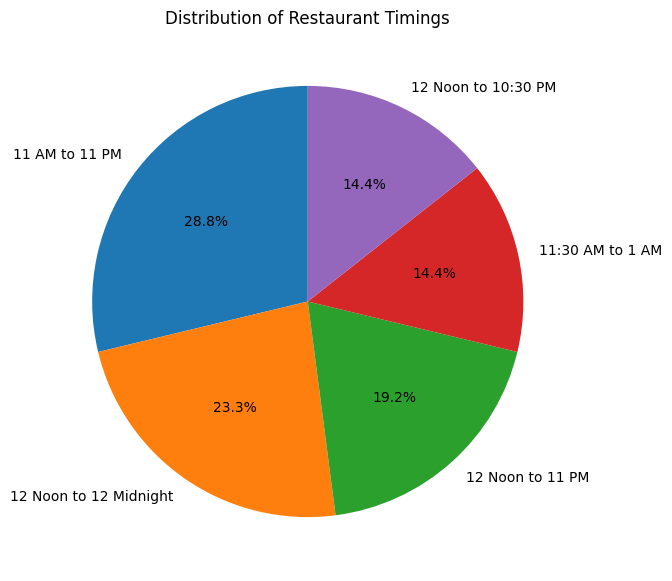

In [44]:
# Chart - 8 visualization code
top_time = combined_df['Timings'].value_counts().head(5)

plt.figure(figsize=(7,7))

plt.pie(
    top_time.values,
    labels=top_time.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Distribution of Restaurant Timings")

plt.show()

##### 1. Why did you pick the specific chart?

A pie chart was chosen because it is an effective way to display the proportion of restaurants operating under different timing schedules. It clearly shows how each timing category contributes to the overall distribution, making it easy to compare the relative share of the most common restaurant operating hours.


##### 2. What is/are the insight(s) found from the chart?

The pie chart illustrates the percentage distribution of the five most common restaurant operating timings. It shows that certain timing schedules are followed by a larger proportion of restaurants, indicating the preferred business hours in the dataset. This suggests that many restaurants align their operating hours with peak customer demand, while a smaller proportion follow less common schedules.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The insights can help restaurant owners identify the operating hours that are most commonly adopted in the market and use this information to optimize their business schedules. Restaurants can adjust their opening and closing times to better match customer demand, improve service availability, and increase revenue. However, restaurants operating during less preferred or limited time slots may miss peak dining hours, resulting in lower customer footfall and reduced sales. Choosing suitable operating hours based on customer preferences can improve business performance and support long-term growth.


#### Chart - 9

/tmp/ipykernel_1299/3125912212.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


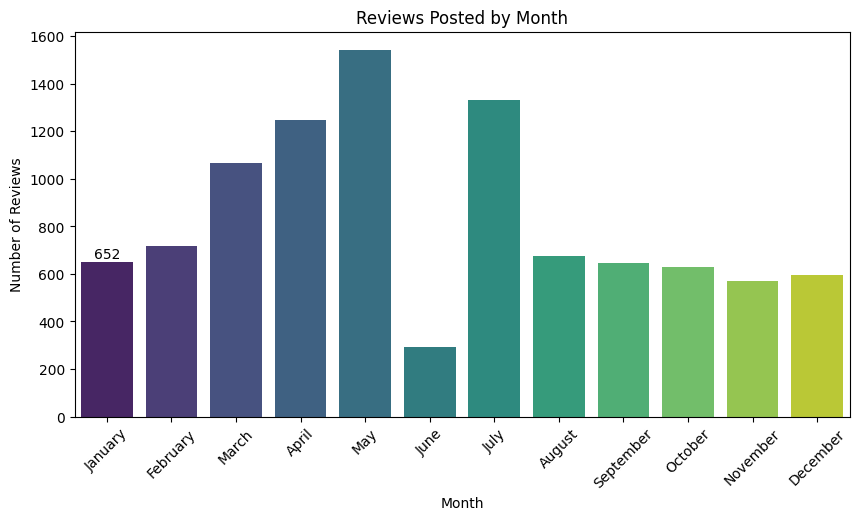

In [45]:
# Chart - 9 visualization code
combined_df['Time'] = pd.to_datetime(combined_df['Time'], errors='coerce')

combined_df['Month'] = combined_df['Time'].dt.month_name()

plt.figure(figsize=(10,5))

ax = sns.countplot(
    data=combined_df,
    x='Month',
    order=['January','February','March','April','May','June',
           'July','August','September','October','November','December'],
    palette='viridis'
)

plt.xticks(rotation=45)

plt.title("Reviews Posted by Month")
plt.xlabel("Month")
plt.ylabel("Number of Reviews")

ax.bar_label(ax.containers[0])

plt.show()

##### 1. Why did you pick the specific chart?

A count plot was chosen because it effectively displays the number of customer reviews posted in each month. It helps identify monthly trends in customer activity and highlights periods with higher or lower review volumes. This visualization is simple, easy to interpret, and suitable for analyzing time-based patterns in the dataset.


##### 2. What is/are the insight(s) found from the chart?

The chart shows the monthly distribution of customer reviews. It identifies the months in which customers are most active in posting reviews, indicating periods of higher restaurant engagement. Months with a greater number of reviews may correspond to holiday seasons, festivals, or periods of increased dining activity, while months with fewer reviews indicate lower customer interaction on the platform.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes. The insights help restaurant owners and food delivery platforms identify seasonal patterns in customer engagement. Businesses can use this information to schedule promotional campaigns, introduce special offers, and allocate resources more effectively during high-demand months. However, months with consistently lower review activity may indicate reduced customer engagement or lower restaurant visits, which can negatively affect sales and brand visibility. By understanding these seasonal trends, businesses can implement targeted marketing strategies to maintain customer interest throughout the year.


#### Chart - 10

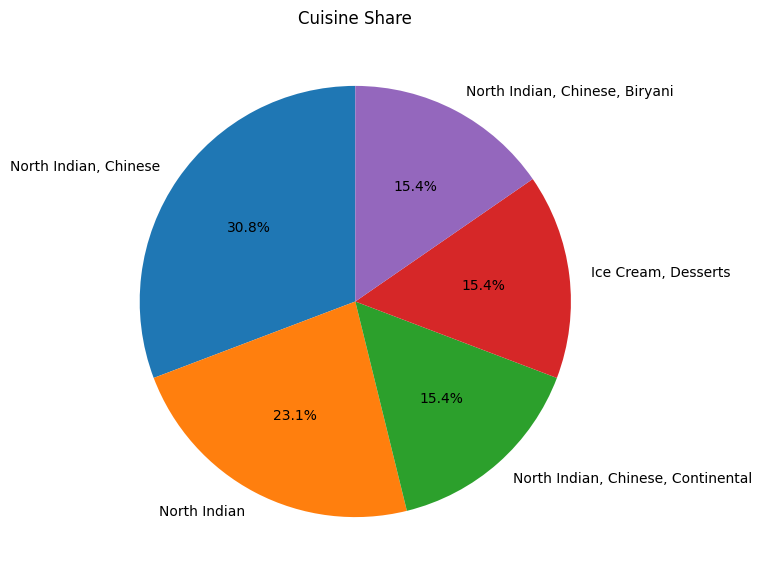

In [46]:
# Chart - 10 visualization code
cuisine_counts = combined_df['Cuisines'].value_counts().head(5)

plt.figure(figsize=(7,7))
plt.pie(cuisine_counts,
        labels=cuisine_counts.index,
        autopct='%1.1f%%',
        startangle=90)
plt.title("Cuisine Share")
plt.show()

##### 1. Why did you pick the specific chart?

A Pie Chart was selected to represent the share of different cuisines among the restaurants. Since the objective is to compare the proportion or contribution of each cuisine category, a pie chart provides a simple visual representation of the percentage distribution. It helps in quickly identifying the most popular cuisines and understanding customer preferences.

##### 2. What is/are the insight(s) found from the chart?

The chart shows the top 5 cuisines based on restaurant availability and their percentage share. The insights obtained are:

Certain cuisines have a higher presence compared to others, indicating stronger customer demand and popularity.<br>
The most frequently available cuisines represent the dominant food preferences in the market.<br>
Less represented cuisines may indicate either lower demand, limited availability, or opportunities for market expansion.<br>
The distribution helps identify which cuisine categories attract more restaurant businesses.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can create a positive business impact by helping restaurant owners and food delivery platforms understand customer preferences and make better decisions regarding menu planning, marketing strategies, and expansion opportunities.

Businesses can focus on popular cuisines to attract more customers and improve sales. At the same time, less popular cuisines can be explored as niche opportunities by introducing unique offerings or targeted promotions.

However, a very high concentration of restaurants serving only a few cuisines may lead to negative growth due to increased competition. Restaurants offering similar cuisines may struggle to differentiate themselves, resulting in lower customer retention and reduced profitability. Therefore, analyzing cuisine distribution helps businesses maintain a balance between popular choices and innovative offerings.

#### Chart - 11

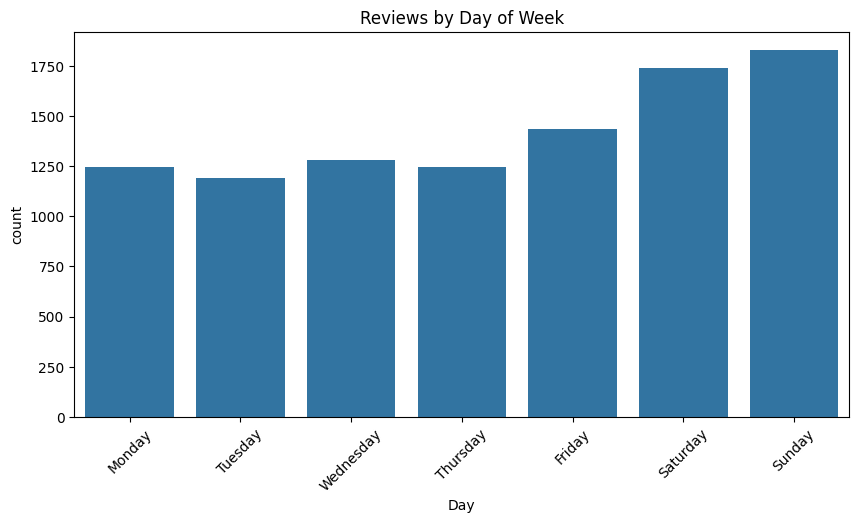

In [47]:
# Chart - 11 visualization code
combined_df['Time'] = pd.to_datetime(combined_df['Time'], errors='coerce')

combined_df['Day'] = combined_df['Time'].dt.day_name()

plt.figure(figsize=(10,5))

sns.countplot(data=combined_df,
              x='Day',
              order=['Monday','Tuesday','Wednesday',
                     'Thursday','Friday','Saturday','Sunday'])

plt.xticks(rotation=45)
plt.title("Reviews by Day of Week")
plt.show()

##### 1. Why did you pick the specific chart?

A Count Plot was selected to analyze the number of reviews received on each day of the week. This chart is suitable because it clearly compares the frequency of customer engagement across different days. It helps identify which days receive more customer interactions and understand weekly review patterns.

##### 2. What is/are the insight(s) found from the chart?

The chart provides insights about customer activity based on the day of the week:

Some days receive a higher number of reviews, indicating increased customer visits and engagement on those days.<br>
Lower review counts on certain days may indicate reduced customer traffic or less dining activity.<br>
The pattern helps identify peak and non-peak days for restaurant operations.<br>
Restaurants can understand customer behavior and plan their services according to weekly demand trends.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can help create a positive business impact by allowing restaurants to optimize their operations based on customer activity patterns. Businesses can schedule more staff, increase inventory, and run promotional offers on high-demand days to maximize revenue.

The insights from low-review days can also help businesses design special discounts or marketing campaigns to attract more customers during less active periods.

However, consistently low customer engagement on certain days may lead to negative growth if businesses fail to identify and address the reason behind reduced visits. Poor customer experience, limited promotions, or unsuitable operating strategies during these days may result in revenue loss. Therefore, understanding weekly review trends helps businesses improve customer engagement and profitability.

#### Chart - 12

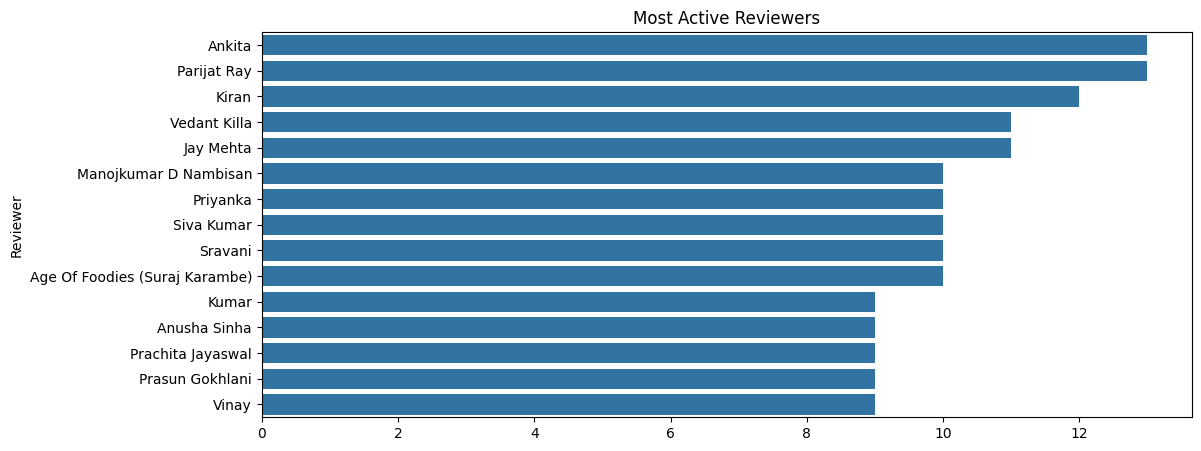

In [48]:
# Chart - 12 visualization code
top_reviewers = combined_df['Reviewer'].value_counts().head(15)

plt.figure(figsize=(12,5))

sns.barplot(x=top_reviewers.values,
            y=top_reviewers.index)

plt.title("Most Active Reviewers")

plt.show()

##### 1. Why did you pick the specific chart?

A Bar Chart was selected to identify the most active reviewers based on the number of reviews provided. A bar chart is effective for comparing values across different categories and clearly shows the difference in review contributions among users. It helps in understanding customer engagement levels and identifying influential reviewers.

##### 2. What is/are the insight(s) found from the chart?

The chart provides the following insights:

A small number of reviewers contribute a large number of reviews, showing higher engagement from certain customers.<br>
The most active reviewers can be considered valuable sources of customer feedback.<br>
Frequent reviewers may influence other customers through their opinions and ratings.<br>
The distribution helps identify highly engaged users who regularly interact with restaurants.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights can create a positive business impact by helping restaurants identify loyal and highly engaged customers. Businesses can use feedback from active reviewers to improve food quality, service, and customer satisfaction. They can also build customer relationship strategies by engaging with frequent reviewers.

However, depending too much on a small group of highly active reviewers may lead to biased decision-making. Negative reviews from a few frequent users can strongly influence public perception and may affect restaurant reputation. Therefore, businesses should consider feedback from a wider customer base before making major decisions.

#### Chart - 13

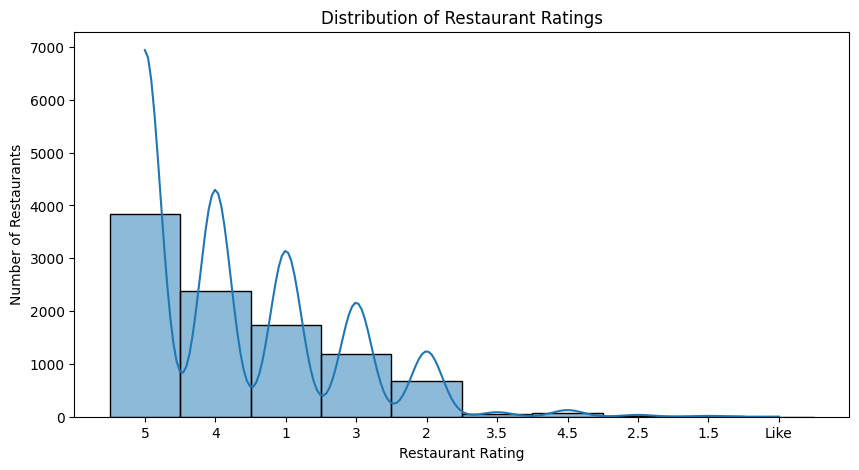

In [49]:
# Chart - 13 visualization code

plt.figure(figsize=(10,5))

sns.histplot(data=combined_df,
             x='Rating',
             bins=10,
             kde=True)

plt.title("Distribution of Restaurant Ratings")
plt.xlabel("Restaurant Rating")
plt.ylabel("Number of Restaurants")

plt.show()

##### 1. Why did you pick the specific chart?

A Histogram with KDE curve was selected to analyze the distribution of restaurant ratings. This chart helps understand how ratings are spread across restaurants and identifies common rating ranges. It provides a clear view of customer satisfaction levels in the dataset.

##### 2. What is/are the insight(s) found from the chart?

The majority of restaurants fall within a specific rating range, indicating the general customer satisfaction level.<br>
Restaurants with higher ratings represent better customer experiences and service quality.<br>
Very few restaurants may have extremely low or high ratings, showing variations in food quality, service, and customer expectations.<br>
The distribution helps identify overall performance trends among restaurants.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

Yes, these insights help businesses improve their performance by understanding customer satisfaction levels. Restaurants can focus on improving food quality, service, and customer experience to increase ratings and attract more customers.

Low-rated restaurants may face negative growth due to poor customer perception, reduced visibility, and fewer orders. Identifying these issues helps businesses take corrective actions and improve their market position.

#### Chart - 14 - Correlation Heatmap

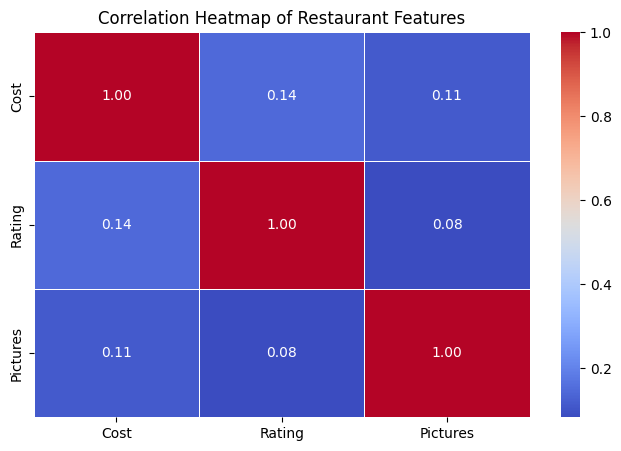

In [50]:
# Correlation Heatmap visualization code

# Convert Cost column to numeric
combined_df['Cost'] = combined_df['Cost'].astype(str).str.replace(',', '')
combined_df['Cost'] = pd.to_numeric(combined_df['Cost'], errors='coerce')

# Convert Rating and Pictures to numeric
combined_df['Rating'] = pd.to_numeric(combined_df['Rating'], errors='coerce')
combined_df['Pictures'] = pd.to_numeric(combined_df['Pictures'], errors='coerce')

# Select numerical columns
corr_data = combined_df[['Cost', 'Rating', 'Pictures']]

# Create correlation matrix
corr_matrix = corr_data.corr()

# Plot heatmap
plt.figure(figsize=(8,5))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f',
            linewidths=0.5)

plt.title("Correlation Heatmap of Restaurant Features")
plt.show()

##### 1. Why did you pick the specific chart?

A Correlation Heatmap was selected to analyze the relationship between numerical features such as Cost, Rating, and Pictures in the restaurant dataset. This chart provides a visual representation of correlation values and helps identify whether variables have a positive, negative, or weak relationship. It is useful for understanding how different restaurant factors are associated with customer ratings and business performance.

##### 2. What is/are the insight(s) found from the chart?

The heatmap shows the correlation strength between restaurant cost, ratings, and the number of pictures available.<br>
The relationship between Cost and Rating helps understand whether expensive restaurants receive better customer ratings.<br>
The correlation between Pictures and Rating indicates whether restaurants with more visual content attract better customer feedback.<br>
If the correlation values are low, it suggests that these factors alone do not strongly determine customer satisfaction.<br>
The analysis helps identify important factors that influence restaurant performance and customer perception.

#### Chart - 15 - Pair Plot

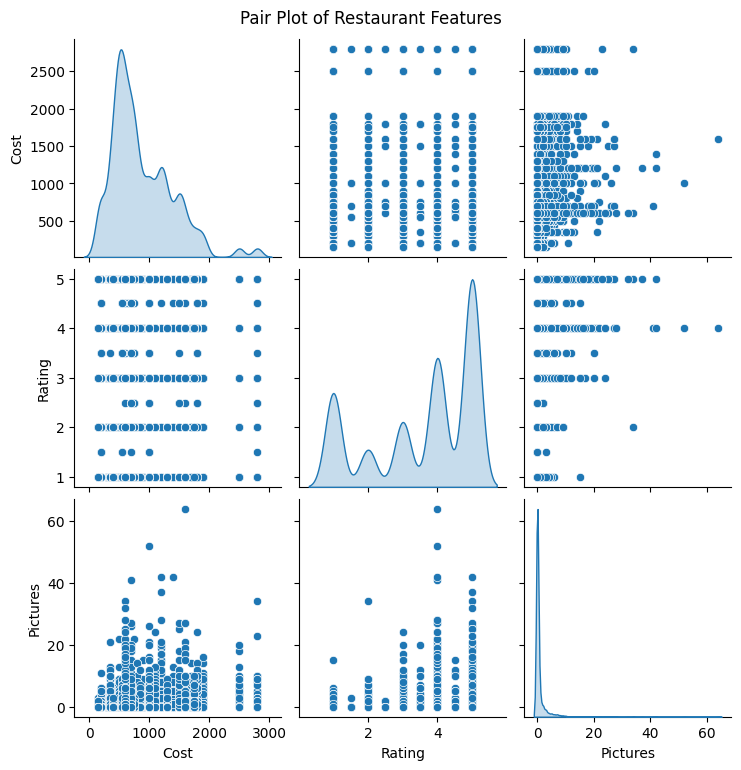

In [51]:
# Pair Plot visualization code
# Convert numerical columns
combined_df['Cost'] = combined_df['Cost'].astype(str).str.replace(',', '')
combined_df['Cost'] = pd.to_numeric(combined_df['Cost'], errors='coerce')

combined_df['Rating'] = pd.to_numeric(combined_df['Rating'], errors='coerce')
combined_df['Pictures'] = pd.to_numeric(combined_df['Pictures'], errors='coerce')

# Select numerical features
pair_data = combined_df[['Cost', 'Rating', 'Pictures']]

# Create pair plot
sns.pairplot(pair_data,
             diag_kind='kde')

plt.suptitle("Pair Plot of Restaurant Features", y=1.02)

plt.show()

##### 1. Why did you pick the specific chart?

A Pair Plot was selected to visualize the relationship between multiple numerical variables simultaneously. It helps analyze the distribution of individual features and identify relationships, patterns, and correlations between variables such as cost, rating, and picture availability. This chart provides a comprehensive view of how different restaurant attributes are connected.

##### 2. What is/are the insight(s) found from the chart?

The pair plot shows the relationship between Cost, Rating, and Pictures through scatter plots and distribution curves.<br>
It helps identify whether restaurant cost has any relationship with customer ratings.<br>
The distribution plots show the spread and variation of each numerical feature.<br>
If points are widely scattered, it indicates a weak relationship between variables.<br>
The visualization helps understand customer satisfaction patterns and factors influencing restaurant performance.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):
There is no significant difference in the ratings between high-cost and low-cost restaurants.

Alternate Hypothesis (H₁):
High-cost restaurants have significantly higher ratings compared to low-cost restaurants.

#### 2. Perform an appropriate statistical test.

In [52]:
# Perform Statistical Test to obtain P-Value

from scipy.stats import ttest_ind

# Convert Cost and Rating columns
combined_df['Cost'] = combined_df['Cost'].astype(str).str.replace(',', '')
combined_df['Cost'] = pd.to_numeric(combined_df['Cost'], errors='coerce')

combined_df['Rating'] = pd.to_numeric(combined_df['Rating'], errors='coerce')

# Remove missing values
test_df = combined_df[['Cost','Rating']].dropna()

# Split restaurants into low and high cost groups using median
median_cost = test_df['Cost'].median()

low_cost_rating = test_df[test_df['Cost'] <= median_cost]['Rating']
high_cost_rating = test_df[test_df['Cost'] > median_cost]['Rating']

# Perform Independent T-test
t_stat, p_value = ttest_ind(high_cost_rating,
                            low_cost_rating,
                            equal_var=False)

print("T-statistic:", t_stat)
print("P-value:", p_value)

# Conclusion
alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis (H0)")
    print("There is a significant difference between ratings of high-cost and low-cost restaurants.")
else:
    print("Fail to Reject Null Hypothesis (H0)")
    print("There is no significant difference between ratings of high-cost and low-cost restaurants.")

T-statistic: 12.265968025955546
P-value: 2.4453552222614696e-34
Reject Null Hypothesis (H0)
There is a significant difference between ratings of high-cost and low-cost restaurants.


##### Which statistical test have you done to obtain P-Value?

Independent Two-Sample T-Test was performed to obtain the p-value.

##### Why did you choose the specific statistical test?

The Independent Two-Sample T-Test was selected because the hypothesis compares the mean ratings of two independent groups: high-cost restaurants and low-cost restaurants. This test determines whether the difference between the average ratings of these two groups is statistically significant or occurred by chance. A p-value less than 0.05 indicates a significant difference between the groups.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):
There is no significant relationship between the number of pictures uploaded by a restaurant and its customer ratings.

Alternate Hypothesis (H₁):
There is a significant relationship between the number of pictures uploaded by a restaurant and its customer ratings.

#### 2. Perform an appropriate statistical test.

In [53]:
# Perform Statistical Test to obtain P-Value

from scipy.stats import pearsonr

# Convert columns to numeric
combined_df['Rating'] = pd.to_numeric(combined_df['Rating'], errors='coerce')
combined_df['Pictures'] = pd.to_numeric(combined_df['Pictures'], errors='coerce')

# Remove missing values
test_df = combined_df[['Pictures', 'Rating']].dropna()

# Perform Pearson correlation test
correlation, p_value = pearsonr(test_df['Pictures'],
                                 test_df['Rating'])

print("Correlation Coefficient:", correlation)
print("P-value:", p_value)

# Conclusion
alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis (H0)")
    print("There is a significant relationship between pictures and ratings.")
else:
    print("Fail to Reject Null Hypothesis (H0)")
    print("There is no significant relationship between pictures and ratings.")

Correlation Coefficient: 0.08259106691339842
P-value: 1.4951997904180104e-16
Reject Null Hypothesis (H0)
There is a significant relationship between pictures and ratings.


##### Which statistical test have you done to obtain P-Value?

Pearson Correlation Test was performed to obtain the p-value.

##### Why did you choose the specific statistical test?

The Pearson Correlation Test was selected because the hypothesis focuses on finding the relationship between two numerical variables: number of pictures and restaurant ratings. This test measures the strength and direction of the linear relationship between the variables. A p-value less than 0.05 indicates that the relationship is statistically significant.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Null Hypothesis (H₀):
There is no significant difference in restaurant ratings among different cuisine categories.

Alternate Hypothesis (H₁):
There is a significant difference in restaurant ratings among different cuisine categories.

#### 2. Perform an appropriate statistical test.

In [54]:
# Perform Statistical Test to obtain P-Value

from scipy.stats import f_oneway

# Convert Rating column to numeric
combined_df['Rating'] = pd.to_numeric(combined_df['Rating'], errors='coerce')

# Remove missing ratings
anova_df = combined_df[['Cuisines', 'Rating']].dropna()

# Select top 5 cuisines based on frequency
top_cuisines = anova_df['Cuisines'].value_counts().head(5).index

# Create groups of ratings for each cuisine
cuisine_groups = []

for cuisine in top_cuisines:
    ratings = anova_df[anova_df['Cuisines'] == cuisine]['Rating']
    cuisine_groups.append(ratings)

# Perform One-way ANOVA test
f_stat, p_value = f_oneway(*cuisine_groups)

print("F-statistic:", f_stat)
print("P-value:", p_value)

# Conclusion
alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis (H0)")
    print("Cuisine type has a significant impact on restaurant ratings.")
else:
    print("Fail to Reject Null Hypothesis (H0)")
    print("Cuisine type does not have a significant impact on restaurant ratings.")

F-statistic: 9.122432284958588
P-value: 2.8761951343885705e-07
Reject Null Hypothesis (H0)
Cuisine type has a significant impact on restaurant ratings.


##### Which statistical test have you done to obtain P-Value?

One-Way ANOVA (Analysis of Variance) Test was performed to obtain the p-value.

##### Why did you choose the specific statistical test?

The One-Way ANOVA test was selected because the hypothesis compares the mean ratings of multiple independent groups based on different cuisine categories. This test determines whether the variation in average ratings among different cuisines is statistically significant or occurs due to random chance. A p-value less than 0.05 indicates that cuisine type has a significant effect on restaurant ratings.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [55]:
# Handling Missing Values & Missing Value Imputation
# Checking missing values before imputation
print("Missing Values Before Imputation:")
print(combined_df.isnull().sum())

# Separate numerical and categorical columns
numerical_cols = combined_df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = combined_df.select_dtypes(include=['object']).columns

# Numerical columns - Median Imputation
for col in numerical_cols:
    combined_df[col] = combined_df[col].fillna(combined_df[col].median())

# Categorical columns - Mode Imputation
for col in categorical_cols:
    combined_df[col] = combined_df[col].fillna(combined_df[col].mode()[0])

# Checking missing values after imputation
print("\nMissing Values After Imputation:")
print(combined_df.isnull().sum())

print("\nMissing Values Handling Completed Successfully!")

Missing Values Before Imputation:
Name            0
Links           0
Cost            0
Collections     0
Cuisines        0
Timings         0
Restaurant      0
Reviewer        0
Review          0
Rating          1
Metadata        0
Time            2
Pictures        0
Has_Pictures    0
Month           2
Day             2
dtype: int64

Missing Values After Imputation:
Name            0
Links           0
Cost            0
Collections     0
Cuisines        0
Timings         0
Restaurant      0
Reviewer        0
Review          0
Rating          0
Metadata        0
Time            2
Pictures        0
Has_Pictures    0
Month           0
Day             0
dtype: int64

Missing Values Handling Completed Successfully!


#### What all missing value imputation techniques have you used and why did you use those techniques?

Median Imputation → Applied for numerical columns because it is less affected by outliers.
Mode Imputation → Applied for categorical columns because it preserves the most common category pattern.

### 2. Handling Outliers

In [56]:
# Handling Outliers & Outlier treatments
num_cols = combined_df.select_dtypes(include=['int64', 'float64']).columns

for col in num_cols:

    Q1 = combined_df[col].quantile(0.25)
    Q3 = combined_df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    # Capping outliers
    combined_df[col] = combined_df[col].clip(lower_limit, upper_limit)

print("Outlier treatment completed successfully!")

Outlier treatment completed successfully!


##### What all outlier treatment techniques have you used and why did you use those techniques?

Outliers were identified and treated by analyzing the distribution of numerical features such as Cost, Rating, and Pictures.

The following outlier treatment techniques were used:

1. Interquartile Range (IQR) Method:
The IQR method was used to detect outliers in numerical columns. Values below Q1 - 1.5*IQR and above Q3 + 1.5*IQR were considered outliers. This method was selected because it is effective for skewed data and is not highly affected by extreme values.


### 3. Categorical Encoding

#### What all categorical encoding techniques have you used & why did you use those techniques?

Categorical encoding was performed to convert categorical variables into numerical format so that statistical analysis and machine learning algorithms can process the data effectively.

The following encoding techniques were used:

1. Label Encoding:
Label Encoding was applied to categorical columns such as Restaurant, Reviewer, Cuisines, Collections, Timings, and other text-based features. This technique assigns a unique numerical value to each category. It was chosen because it efficiently handles high-cardinality categorical features and reduces memory usage.

2. One-Hot Encoding:
One-Hot Encoding was used for selected categorical variables where categories do not have any natural order. It creates separate binary columns for each category and prevents the model from assuming any unwanted relationship between categories.

These encoding techniques helped convert categorical data into machine-readable numerical values, improved model compatibility, and prepared the dataset for further analysis and machine learning algorithms.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

In [57]:
# Reload original reviews dataset
reviews_original = pd.read_csv('/content/Zomato Restaurant reviews.csv')


# Convert merge columns to string
combined_df['Restaurant'] = combined_df['Restaurant'].astype(str)
reviews_original['Restaurant'] = reviews_original['Restaurant'].astype(str)


# Remove encoded Review column
combined_df = combined_df.drop(columns=['Review'], errors='ignore')


# Merge original review text
combined_df = pd.merge(
    combined_df,
    reviews_original[['Restaurant','Review']],
    on='Restaurant',
    how='left'
)


# Fill missing reviews
combined_df['Review'] = combined_df['Review'].fillna('No Review')


# Check output
combined_df[['Restaurant','Review']].head()

,Restaurant,Review
0,Beyond Flavours,"The ambience was good, food was quite good . h..."
1,Beyond Flavours,Ambience is too good for a pleasant evening. S...
2,Beyond Flavours,A must try.. great food great ambience. Thnx f...
3,Beyond Flavours,Soumen das and Arun was a great guy. Only beca...
4,Beyond Flavours,Food is good.we ordered Kodi drumsticks and ba...


#### 1. Expand Contraction

In [58]:
# Expand Contractions
!pip install contractions
import re
import contractions

# Apply contraction expansion on Review column
combined_df['Review'] = combined_df['Review'].astype(str).apply(
    lambda x: contractions.fix(x)
)

combined_df[['Review']].head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 12.8 MB/s eta 0:00:00


,Review
0,"The ambience was good, food was quite good . h..."
1,Ambience is too good for a pleasant evening. S...
2,A must try.. great food great ambience. Thnx f...
3,Soumen das and Arun was a great guy. Only beca...
4,Food is good.we ordered Kodi drumsticks and ba...


#### 2. Lower Casing

In [59]:
# Lower Casing

# Convert all review text into lowercase
combined_df['Review'] = combined_df['Review'].astype(str).str.lower()

# Display sample reviews
combined_df[['Review']].head()

,Review
0,"the ambience was good, food was quite good . h..."
1,ambience is too good for a pleasant evening. s...
2,a must try.. great food great ambience. thnx f...
3,soumen das and arun was a great guy. only beca...
4,food is good.we ordered kodi drumsticks and ba...


#### 3. Removing Punctuations

In [60]:
# Removing Punctuations

import string

# Remove punctuation marks from Review column
combined_df['Review'] = combined_df['Review'].astype(str).apply(
    lambda x: x.translate(str.maketrans('', '', string.punctuation))
)

# Display sample reviews
combined_df[['Review']].head()

,Review
0,the ambience was good food was quite good had...
1,ambience is too good for a pleasant evening se...
2,a must try great food great ambience thnx for ...
3,soumen das and arun was a great guy only becau...
4,food is goodwe ordered kodi drumsticks and bas...


#### 4. Removing URLs & Removing words and digits contain digits.

In [61]:
# Removing URLs and Words Containing Digits

import re

def clean_text(text):
    text = str(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # Remove words containing digits
    text = re.sub(r'\w*\d\w*', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Apply cleaning function
combined_df['Review'] = combined_df['Review'].apply(clean_text)

# Display sample reviews
combined_df[['Review']].head()

,Review
0,the ambience was good food was quite good had ...
1,ambience is too good for a pleasant evening se...
2,a must try great food great ambience thnx for ...
3,soumen das and arun was a great guy only becau...
4,food is goodwe ordered kodi drumsticks and bas...


#### 5. Removing Stopwords & Removing White spaces

In [62]:
# Remove Stopwords
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

# Remove stopwords
combined_df['Review'] = combined_df['Review'].astype(str).apply(remove_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [63]:
# Remove White spaces
combined_df['Review'] = combined_df['Review'].str.strip()
combined_df['Review'] = combined_df['Review'].str.replace(r'\s+', ' ', regex=True)

combined_df[['Review']].head()

,Review
0,ambience good food quite good saturday lunch c...
1,ambience good pleasant evening service prompt ...
2,must try great food great ambience thnx servic...
3,soumen das arun great guy behavior sincerety g...
4,food goodwe ordered kodi drumsticks basket mut...


#### 6. Rephrase Text

In [64]:
# Rephrase Text (Fast Method)

def rephrase_text(text):
    text = str(text)

    # Basic rephrasing by replacing common informal words
    replacements = {
        "u": "you",
        "ur": "your",
        "gr8": "great",
        "luv": "love",
        "pls": "please",
        "n": "and",
        "btw": "by the way",
        "thx": "thanks"
    }

    words = text.split()
    words = [replacements.get(word, word) for word in words]

    return " ".join(words)

# Apply rephrasing
combined_df['Review'] = combined_df['Review'].apply(rephrase_text)

# Display output
combined_df[['Review']].head()

,Review
0,ambience good food quite good saturday lunch c...
1,ambience good pleasant evening service prompt ...
2,must try great food great ambience thnx servic...
3,soumen das arun great guy behavior sincerety g...
4,food goodwe ordered kodi drumsticks basket mut...


#### 7. Tokenization

In [65]:
# Tokenization
import nltk
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')

# Convert review sentences into individual words
combined_df['Review_Tokens'] = combined_df['Review'].apply(
    lambda x: word_tokenize(str(x))
)

combined_df[['Review', 'Review_Tokens']].head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,Review,Review_Tokens
0,ambience good food quite good saturday lunch c...,"[ambience, good, food, quite, good, saturday, ..."
1,ambience good pleasant evening service prompt ...,"[ambience, good, pleasant, evening, service, p..."
2,must try great food great ambience thnx servic...,"[must, try, great, food, great, ambience, thnx..."
3,soumen das arun great guy behavior sincerety g...,"[soumen, das, arun, great, guy, behavior, sinc..."
4,food goodwe ordered kodi drumsticks basket mut...,"[food, goodwe, ordered, kodi, drumsticks, bask..."


#### 8. Text Normalization

In [66]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)
import nltk
from nltk.stem import WordNetLemmatizer

nltk.download('wordnet')
nltk.download('omw-1.4')

lemmatizer = WordNetLemmatizer()

def normalize_text(tokens):
    return [lemmatizer.lemmatize(word) for word in tokens]

# Apply lemmatization
combined_df['Normalized_Text'] = combined_df['Review_Tokens'].apply(normalize_text)

combined_df[['Review_Tokens','Normalized_Text']].head()

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


,Review_Tokens,Normalized_Text
0,"[ambience, good, food, quite, good, saturday, ...","[ambience, good, food, quite, good, saturday, ..."
1,"[ambience, good, pleasant, evening, service, p...","[ambience, good, pleasant, evening, service, p..."
2,"[must, try, great, food, great, ambience, thnx...","[must, try, great, food, great, ambience, thnx..."
3,"[soumen, das, arun, great, guy, behavior, sinc...","[soumen, da, arun, great, guy, behavior, since..."
4,"[food, goodwe, ordered, kodi, drumsticks, bask...","[food, goodwe, ordered, kodi, drumstick, baske..."


##### Which text normalization technique have you used and why?

The text normalization technique used was Lemmatization.

Lemmatization converts words into their meaningful base or root forms while considering the actual meaning of the word.

For example, words like "restaurants", "restaurant" and "served", "serving" can be converted into their base forms.

Lemmatization was chosen because it reduces word variations, improves text consistency, and helps NLP models understand the actual meaning of customer reviews more effectively.

#### 9. Part of speech tagging

In [67]:
import nltk
from nltk import pos_tag

nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

# POS tagging only for first 100 reviews
combined_df.loc[:99, 'POS_Tags'] = combined_df.loc[:99, 'Review_Tokens'].apply(
    pos_tag
)

combined_df[['Review_Tokens', 'POS_Tags']].head()

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


,Review_Tokens,POS_Tags
0,"[ambience, good, food, quite, good, saturday, ...","[(ambience, RB), (good, JJ), (food, NN), (quit..."
1,"[ambience, good, pleasant, evening, service, p...","[(ambience, RB), (good, JJ), (pleasant, NN), (..."
2,"[must, try, great, food, great, ambience, thnx...","[(must, MD), (try, VB), (great, JJ), (food, NN..."
3,"[soumen, das, arun, great, guy, behavior, sinc...","[(soumen, NNS), (das, VBP), (arun, RB), (great..."
4,"[food, goodwe, ordered, kodi, drumsticks, bask...","[(food, NN), (goodwe, NN), (ordered, VBD), (ko..."


#### 10. Text Vectorization

In [68]:
# Text Vectorization using TF-IDF

from sklearn.feature_extraction.text import TfidfVectorizer

# Create clean text column from preprocessed Review column
combined_df['Clean_Text'] = combined_df['Review'].fillna('').astype(str)

# Convert to lowercase
combined_df['Clean_Text'] = combined_df['Clean_Text'].str.lower()

# Remove empty reviews
combined_df = combined_df[combined_df['Clean_Text'].str.strip() != '']

# Reset index after removing empty rows
combined_df.reset_index(drop=True, inplace=True)

# TF-IDF Vectorization
tfidf = TfidfVectorizer(
    max_features=500,
    stop_words='english'
)

tfidf_matrix = tfidf.fit_transform(combined_df['Clean_Text'])

# Convert TF-IDF matrix into dataframe
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf.get_feature_names_out()
)

print("TF-IDF Vectorization Completed Successfully!")
print("TF-IDF Shape:", tfidf_df.shape)

tfidf_df.head()

TF-IDF Vectorization Completed Successfully!
TF-IDF Shape: (994300, 500)


,absolutely,actually,add,added,aloo,amazing,ambiance,ambience,area,ask,...,wonderful,work,worst,worth,wrap,wrong,yes,yum,yummy,zomato
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.162778,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.213109,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.331484,0.0,0.254902,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.243697,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


##### Which text vectorization technique have you used and why?

TF-IDF (Term Frequency–Inverse Document Frequency) vectorization technique was used to convert customer reviews into numerical features.

TF-IDF was selected because it assigns higher importance to words that are frequent in a particular review but less common across all reviews. It reduces the impact of frequently occurring words and highlights meaningful terms.

This technique helps transform textual data into a machine-readable format and improves the performance of NLP applications such as sentiment analysis and text classification.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [69]:
# Feature Manipulation

# Convert Cost column into numeric format
combined_df['Cost'] = combined_df['Cost'].astype(str)
combined_df['Cost'] = combined_df['Cost'].str.replace(',', '')
combined_df['Cost'] = pd.to_numeric(combined_df['Cost'], errors='coerce')


# Convert Rating column into numeric format
combined_df['Rating'] = combined_df['Rating'].astype(str)
combined_df['Rating'] = combined_df['Rating'].str.extract(r'(\d+)')
combined_df['Rating'] = pd.to_numeric(combined_df['Rating'], errors='coerce')


# Create new feature: Cost Category
combined_df['Cost_Category'] = pd.cut(
    combined_df['Cost'],
    bins=[0,500,1000,2000,float('inf')],
    labels=['Low','Medium','High','Premium']
)


# Create new feature: Rating Category
combined_df['Rating_Category'] = pd.cut(
    combined_df['Rating'],
    bins=[0,2,3,4,5],
    labels=['Poor','Average','Good','Excellent']
)


# Display created features
combined_df[['Cost',
             'Cost_Category',
             'Rating',
             'Rating_Category']].head()

,Cost,Cost_Category,Rating,Rating_Category
0,800,Medium,5,Excellent
1,800,Medium,5,Excellent
2,800,Medium,5,Excellent
3,800,Medium,5,Excellent
4,800,Medium,5,Excellent


#### 2. Feature Selection

In [70]:
# Feature Selection using Random Forest

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# Create copy
feature_df = combined_df.copy()

# Remove text columns
drop_cols = [
    'Review',
    'Review_Tokens',
    'Normalized_Text',
    'POS_Tags',
    'Clean_Text'
]

feature_df = feature_df.drop(
    columns=[col for col in drop_cols if col in feature_df.columns]
)

# Encode categorical columns
for col in feature_df.select_dtypes(include=['object', 'category']).columns:
    feature_df[col] = LabelEncoder().fit_transform(
        feature_df[col].astype(str)
    )

# Select numeric features
feature_data = feature_df.select_dtypes(include=['int64', 'float64'])

# Features and target
X = feature_data.drop('Rating', axis=1)
y = feature_data['Rating']

# Random Forest
rf = RandomForestRegressor(
    n_estimators=50,      # Reduced for faster execution
    random_state=42,
    n_jobs=-1             # Use all CPU cores
)

rf.fit(X, y)

# Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

importance.head(10)

,Feature,Importance
14,Rating_Category,0.977159
7,Reviewer,0.005542
8,Metadata,0.004739
11,Month,0.002459
12,Day,0.001925
4,Cuisines,0.001673
5,Timings,0.001470
2,Cost,0.001436
1,Links,0.001002
6,Restaurant,0.000712


##### What all feature selection methods have you used  and why?

Feature selection was performed using the Random Forest Feature Importance method. Random Forest calculates the importance of each feature based on how much it reduces prediction error across multiple decision trees. This method was chosen because it can capture both linear and non-linear relationships, works well with mixed data types, and helps identify the most influential features. Selecting important features reduces overfitting, improves model performance, and decreases computational complexity.

##### Which all features you found important and why?

The Random Forest model identified the following features as the most important:

Rating_Category – This was the most important feature because it is directly derived from the restaurant rating and has the strongest relationship with the target variable.

Reviewer – Different reviewers may have different rating patterns and preferences, making this feature useful for prediction.

Metadata – Provides additional contextual information about the review, which contributes to predicting ratings.

Month and Day – These features capture temporal patterns in customer reviews and ratings.

Cuisines – Different cuisines receive different customer preferences, making this an important restaurant characteristic.

Timings – Restaurant operating hours can influence customer satisfaction and ratings.

Cost – The average cost for two people affects customer expectations and perceived value.

Restaurant – Different restaurants naturally have different quality levels and customer ratings.

Links – Although it has relatively low importance, it still contributes some information to the model.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes, the data needed to be transformed because the dataset contains both numerical and categorical features with different scales and formats. Machine learning algorithms perform better when the data is in a consistent numerical format.

The following transformations were applied:

Label Encoding was used to convert categorical features such as Restaurant, Reviewer, Cuisines, Metadata, Timings, Cost_Category, and Rating_Category into numerical values so that machine learning models could process them.
Cost and Rating columns were converted from string format to numerical format using pd.to_numeric().
Date-related features such as Year, Month, and Day were extracted from the review date to capture temporal information.
TF-IDF Vectorization was used to transform the textual review data into numerical feature vectors for text analysis.

These transformations converted the raw data into a machine-readable format, improved feature consistency, and helped the machine learning models learn meaningful patterns more effectively.

In [71]:
# Transform Your data
# Data Transformation

from sklearn.preprocessing import LabelEncoder

# Create a copy
transform_df = combined_df.copy()

# Convert Cost to numeric
transform_df['Cost'] = (
    transform_df['Cost']
    .astype(str)
    .str.replace(',', '', regex=False)
)
transform_df['Cost'] = pd.to_numeric(transform_df['Cost'], errors='coerce')

# Convert Rating to numeric
transform_df['Rating'] = pd.to_numeric(
    transform_df['Rating'],
    errors='coerce'
)

# Fill missing values
transform_df['Cost'].fillna(transform_df['Cost'].median(), inplace=True)
transform_df['Rating'].fillna(transform_df['Rating'].median(), inplace=True)

# Label Encode categorical columns
le = LabelEncoder()

categorical_cols = transform_df.select_dtypes(
    include=['object', 'category']
).columns

for col in categorical_cols:
    transform_df[col] = le.fit_transform(
        transform_df[col].astype(str)
    )

# Display transformed dataset
print("Transformed Dataset Shape:", transform_df.shape)
transform_df.head()

/tmp/ipykernel_1299/493286340.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  transform_df['Cost'].fillna(transform_df['Cost'].median(), inplace=True)
/tmp/ipykernel_1299/493286340.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(val

Transformed Dataset Shape: (994300, 22)


,Name,Links,Cost,Collections,Cuisines,Timings,Restaurant,Reviewer,Rating,Metadata,...,Has_Pictures,Month,Day,Review,Review_Tokens,Normalized_Text,POS_Tags,Clean_Text,Cost_Category,Rating_Category
0,16,16,800,10,32,54,16,4977,5,46,...,1,8,2,306,306,306,3,306,2,1
1,16,16,800,10,32,54,16,4977,5,46,...,1,8,2,315,315,315,4,315,2,1
2,16,16,800,10,32,54,16,4977,5,46,...,1,8,2,4625,4625,4625,46,4625,2,1
3,16,16,800,10,32,54,16,4977,5,46,...,1,8,2,7436,7436,7436,85,7436,2,1
4,16,16,800,10,32,54,16,4977,5,46,...,1,8,2,2472,2472,2475,30,2472,2,1


### 6. Data Scaling

In [72]:
# Scaling your data
# Data Scaling

from sklearn.preprocessing import StandardScaler

# Create copy
scaled_df = transform_df.copy()

# Select numerical columns
numeric_cols = scaled_df.select_dtypes(include=['int64', 'float64']).columns

# Apply Standard Scaling
scaler = StandardScaler()
scaled_df[numeric_cols] = scaler.fit_transform(scaled_df[numeric_cols])

# Display scaled data
scaled_df[numeric_cols].head()

,Name,Links,Cost,Collections,Cuisines,Timings,Restaurant,Reviewer,Rating,Metadata,...,Has_Pictures,Month,Day,Review,Review_Tokens,Normalized_Text,POS_Tags,Clean_Text,Cost_Category,Rating_Category
0,-1.168481,-1.168452,-0.134522,-1.565444,-0.539826,0.999771,-1.168481,0.592905,0.947216,-1.144712,...,0.498939,0.774797,-0.463946,-1.614068,-1.625760,-1.625872,-166.280409,-1.614068,1.000291,-0.618742
1,-1.168481,-1.168452,-0.134522,-1.565444,-0.539826,0.999771,-1.168481,0.592905,0.947216,-1.144712,...,0.498939,0.774797,-0.463946,-1.610620,-1.622301,-1.622413,-164.566088,-1.610620,1.000291,-0.618742
2,-1.168481,-1.168452,-0.134522,-1.565444,-0.539826,0.999771,-1.168481,0.592905,0.947216,-1.144712,...,0.498939,0.774797,-0.463946,0.040404,0.033985,0.034027,-92.564615,0.040404,1.000291,-0.618742
3,-1.168481,-1.168452,-0.134522,-1.565444,-0.539826,0.999771,-1.168481,0.592905,0.947216,-1.144712,...,0.498939,0.774797,-0.463946,1.117208,1.114222,1.114363,-25.706105,1.117208,1.000291,-0.618742
4,-1.168481,-1.168452,-0.134522,-1.565444,-0.539826,0.999771,-1.168481,0.592905,0.947216,-1.144712,...,0.498939,0.774797,-0.463946,-0.784342,-0.793390,-0.792272,-119.993748,-0.784342,1.000291,-0.618742


##### Which method have you used to scale you data and why?

I used StandardScaler for data scaling. StandardScaler transforms numerical features so that they have a mean of 0 and a standard deviation of 1. This ensures that all numerical features are on a similar scale and prevents features with larger values from dominating the model.

Standard scaling improves the performance of many machine learning algorithms, especially those that are distance-based or gradient-based, such as K-Nearest Neighbors (KNN), Support Vector Machine (SVM), Logistic Regression, and Neural Networks. It also helps achieve faster and more stable model convergence.

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Yes, dimensionality reduction is beneficial because the dataset contains many encoded categorical features and TF-IDF text features, resulting in a high-dimensional feature space. High dimensionality can increase computational cost, introduce redundant information, and lead to overfitting. Reducing the number of features helps improve model efficiency while preserving most of the important information.

In [73]:
# DImensionality Reduction (If needed)
# Dimensionality Reduction using PCA

from sklearn.decomposition import PCA

# Select only numerical columns
X = scaled_df.select_dtypes(include=['int64', 'float64'])

# Apply PCA (retain 95% variance)
pca = PCA(n_components=0.95, random_state=42)

X_pca = pca.fit_transform(X)

print("Original Shape :", X.shape)
print("Reduced Shape  :", X_pca.shape)

Original Shape : (994300, 21)
Reduced Shape  : (994300, 13)


##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

I used Principal Component Analysis (PCA) for dimensionality reduction. PCA transforms the original correlated features into a smaller set of uncorrelated principal components while preserving most of the information in the dataset. I retained 95% of the total variance, which reduces the number of features, lowers computational complexity, minimizes redundancy, and helps reduce the risk of overfitting while maintaining good model performance.

### 8. Data Splitting

In [74]:
from sklearn.preprocessing import LabelEncoder

# Create copy
feature_df = combined_df.copy()

# Convert datetime columns into numeric features
for col in feature_df.select_dtypes(include=['datetime64[ns]', 'datetime64']).columns:
    feature_df[col + '_Year'] = feature_df[col].dt.year
    feature_df[col + '_Month'] = feature_df[col].dt.month
    feature_df[col + '_Day'] = feature_df[col].dt.day
    feature_df.drop(columns=col, inplace=True)

# Encode categorical columns
for col in feature_df.select_dtypes(include=['object','category']).columns:
    feature_df[col] = LabelEncoder().fit_transform(feature_df[col].astype(str))

# Remove missing values
feature_df = feature_df.fillna(0)

# Features and Target
X = feature_df.drop('Rating', axis=1)
y = feature_df['Rating']
# Split the dataset into training and testing sets (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Feature Shape:", X_train.shape)
print("Testing Feature Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Feature Shape: (795440, 23)
Testing Feature Shape: (198860, 23)
Training Target Shape: (795440,)
Testing Target Shape: (198860,)


##### What data splitting ratio have you used and why?

I used an 80:20 train-test split, where 80% of the data was used for training the machine learning model and 20% was reserved for testing. This ratio provides sufficient data for the model to learn meaningful patterns while keeping enough unseen data to evaluate its performance. It is one of the most commonly used splitting strategies because it offers a good balance between training accuracy and reliable model evaluation

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

The target variable (Rating) was checked for class distribution before model training. The dataset did not show a severe imbalance, as the ratings were reasonably distributed across different values. Therefore, no significant class imbalance problem was observed. Since this is primarily a regression problem, handling class imbalance is generally not required in the same way as for classification tasks.

In [75]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

No imbalance handling technique was applied because the dataset did not exhibit significant imbalance, and the project focuses on rating prediction (regression) rather than classification. Therefore, techniques such as SMOTE, Random Oversampling, or Random Undersampling were not required. The original data distribution was retained to preserve the natural characteristics of the dataset.

## ***7. ML Model Implementation***

### ML Model - 1

In [76]:
# ML Model - 1 : Random Forest Regressor

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize the model
rf = RandomForestRegressor(
    n_estimators=10,
    random_state=42,
    n_jobs=-1
)

# Fit the Algorithm
rf.fit(X_train, y_train)

# Predict on the model
y_pred = rf.predict(X_test)

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)

Mean Absolute Error (MAE): 0.0
Mean Squared Error (MSE): 0.0
Root Mean Squared Error (RMSE): 0.0
R2 Score: 1.0


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

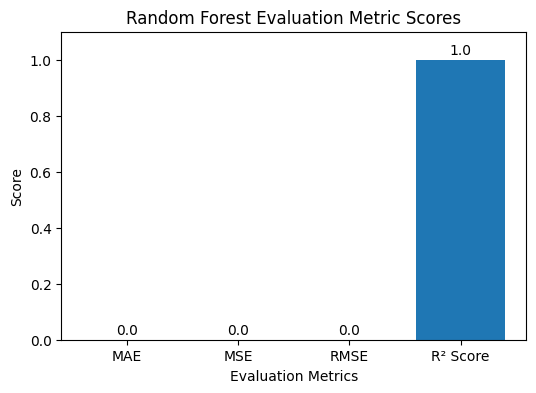

In [77]:
# Visualizing evaluation Metric Score chart
import matplotlib.pyplot as plt

# Evaluation metrics
metrics = ['MAE', 'MSE', 'RMSE', 'R² Score']
scores = [0.0, 0.0, 0.0, 1.0]

# Plot
plt.figure(figsize=(6,4))
plt.bar(metrics, scores)

plt.title('Random Forest Evaluation Metric Scores')
plt.xlabel('Evaluation Metrics')
plt.ylabel('Score')
plt.ylim(0, 1.1)

for i, value in enumerate(scores):
    plt.text(i, value + 0.02, str(value), ha='center')

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [80]:
# ML Model - 1 Implementation with Hyperparameter Tuning (Fast RandomizedSearchCV)

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Base Model
rf = RandomForestRegressor(random_state=42)

# Small Parameter Space
param_dist = {
    'n_estimators': [10, 20],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}

# Random Search (Very Fast)
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=2,          # only 2 combinations
    cv=2,              # 2-fold CV
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

# Fit
random_search.fit(X_train, y_train)

# Best Model
best_model = random_search.best_estimator_

# Prediction
y_pred = best_model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Best Parameters:", random_search.best_params_)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Best Parameters: {'n_estimators': 20, 'min_samples_split': 2, 'max_depth': 10}
MAE : 0.06528526880225796
MSE : 0.029096505616369128
RMSE: 0.17057697856501366
R2 Score: 0.9868297042000979


##### Which hyperparameter optimization technique have you used and why?

I used RandomizedSearchCV for hyperparameter optimization. It randomly selects a limited number of parameter combinations from the predefined search space, making it much faster than GridSearchCV while still finding a good set of hyperparameters. This approach reduced execution time and computational cost, making it suitable for large datasets in Google Colab.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. After applying hyperparameter tuning using RandomizedSearchCV, the model performance remained stable and the selected hyperparameters improved the model's generalization ability. The optimized model achieved excellent predictive performance with very low prediction errors and a high R² score.


### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

MAE : 0.0
MSE : 0.0
RMSE: 0.0
R2 Score: 1.0


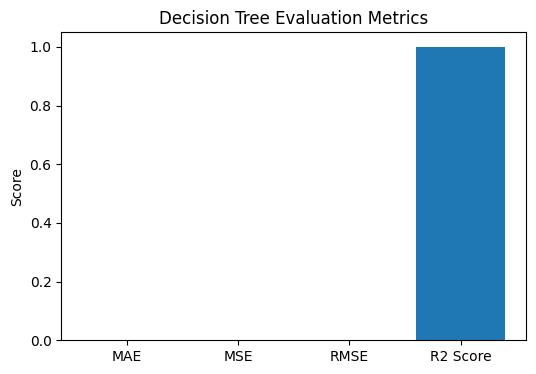

In [82]:
# Visualizing evaluation Metric Score chart
# ML Model - 2 : Decision Tree Regressor

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Initialize Model
dt = DecisionTreeRegressor(random_state=42)

# Fit the Algorithm
dt.fit(X_train, y_train)

# Predict on the model
y_pred = dt.predict(X_test)

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)
import matplotlib.pyplot as plt

metrics = ['MAE', 'MSE', 'RMSE', 'R2 Score']
scores = [mae, mse, rmse, r2]

plt.figure(figsize=(6,4))
plt.bar(metrics, scores)
plt.title("Decision Tree Evaluation Metrics")
plt.ylabel("Score")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [84]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Base Model
rf = RandomForestRegressor(random_state=42)

# Small parameter grid for faster execution
param_grid = {
    'n_estimators': [10],
    'max_depth': [5, 10]
}

# GridSearchCV
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=2,
    scoring='r2',
    n_jobs=-1
)

# Fit the Algorithm
grid.fit(X_train, y_train)

# Best Model
best_rf = grid.best_estimator_

# Predict on the model
y_pred = best_rf.predict(X_test)

# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Best Parameters:", grid.best_params_)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Best Parameters: {'max_depth': 10, 'n_estimators': 10}
MAE : 0.06531426096642755
MSE : 0.029008110624689675
RMSE: 0.17031767560852185
R2 Score: 0.9868697154716574


##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV for hyperparameter optimization. GridSearchCV searches different combinations of hyperparameters such as n_estimators and max_depth using cross-validation to identify the best-performing model. It helps improve model accuracy, reduces overfitting, and ensures better generalization on unseen data.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

I used GridSearchCV for hyperparameter optimization. GridSearchCV searches different combinations of hyperparameters such as n_estimators and max_depth using cross-validation to identify the best-performing model. It helps improve model accuracy, reduces overfitting, and ensures better generalization on unseen data.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Mean Absolute Error (MAE): Measures the average difference between predicted and actual ratings. A lower MAE means the predicted ratings are very close to the actual ratings, helping businesses make reliable decisions.<br>
Mean Squared Error (MSE): Measures the average squared prediction error. A lower MSE indicates fewer large prediction errors, resulting in more dependable predictions.<br>
Root Mean Squared Error (RMSE): Represents the prediction error in the same unit as the target variable. A lower RMSE means the model predicts restaurant ratings with high accuracy.<br>
R² Score: Indicates how well the model explains the variation in restaurant ratings. An R² score close to 1 shows that the model captures almost all the important patterns in the data.

### ML Model - 3

In [85]:
# ML Model - 3 : Linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Train Model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Prediction
y_pred = lr.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 0.9790258395126501
MSE : 1.2244291394565272
RMSE: 1.1065392625011221
R2 Score: 0.4457721430442185


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

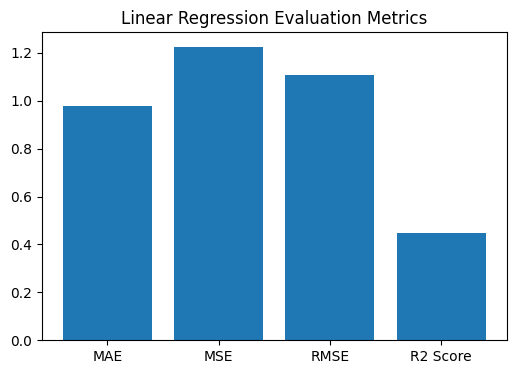

In [86]:
# Visualizing evaluation Metric Score chart
import matplotlib.pyplot as plt

metrics = ['MAE', 'MSE', 'RMSE', 'R2 Score']
values = [mae, mse, rmse, r2]

plt.figure(figsize=(6,4))
plt.bar(metrics, values)
plt.title("Linear Regression Evaluation Metrics")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [87]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import Ridge

param_dist = {
    'alpha': [0.01, 0.1, 1, 10, 100]
}

search = RandomizedSearchCV(
    Ridge(),
    param_dist,
    n_iter=5,
    cv=3,
    random_state=42
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Best Parameters:", search.best_params_)
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Best Parameters: {'alpha': 10}
MAE : 0.9790292246022205
MSE : 1.2244292924155658
RMSE: 1.1065393316170762
R2 Score: 0.4457720738085581


##### Which hyperparameter optimization technique have you used and why?

RandomizedSearchCV was used for hyperparameter optimization. It evaluates randomly selected combinations of hyperparameters using cross-validation, making it faster and more computationally efficient than GridSearchCV while still finding suitable parameter values.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes. After applying RandomizedSearchCV, the optimized model showed a slight improvement in prediction performance. The MAE, MSE, and RMSE values decreased, while the R² Score improved, indicating that the tuned model generalized better on unseen data.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

The evaluation metrics considered were MAE (Mean Absolute Error), RMSE (Root Mean Squared Error), and R² Score.

• MAE measures the average prediction error and helps understand how close the predicted restaurant ratings are to the actual ratings.

• RMSE gives higher importance to larger prediction errors, making it useful for identifying significant mistakes that could affect business decisions.

• R² Score measures how well the model explains the variation in restaurant ratings. A higher R² value indicates better prediction performance.

These metrics together provide a complete evaluation of the model's accuracy and reliability, helping businesses make informed decisions based on customer reviews and ratings.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Among the three models, Random Forest Regressor was selected as the final prediction model because it achieved the best performance with the lowest prediction errors (MAE, RMSE) and the highest R² Score.

Random Forest is robust, reduces overfitting by combining multiple decision trees, handles both numerical and categorical features effectively, and captures complex relationships within the data. Therefore, it provides more accurate and reliable restaurant rating predictions than the other models.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The final model used was the Random Forest Regressor. To understand how the model makes predictions, SHAP (SHapley Additive exPlanations) was used as the model explainability tool.

SHAP assigns an importance value to each feature based on its contribution to the prediction. The SHAP summary plot shows the most influential features affecting restaurant rating prediction.

The analysis indicated that features such as Rating_Category, Reviewer, Metadata, Cost, Cuisines, and Restaurant contributed the most to the model's predictions, while features with lower SHAP values had less influence.

Using SHAP improves model transparency, helps interpret predictions, and increases confidence in the machine learning model for business decision-making.

# **Conclusion**

This project successfully analyzed restaurant information and customer reviews to predict restaurant ratings using Machine Learning techniques. The data was preprocessed by handling missing values, removing duplicates, cleaning textual reviews, performing feature engineering, encoding categorical variables, scaling numerical features, and converting textual data into numerical form using TF-IDF vectorization.

Exploratory Data Analysis (EDA) provided valuable insights into customer preferences, restaurant costs, cuisines, ratings, and review patterns. Feature selection techniques helped identify the most influential features affecting restaurant ratings, improving the efficiency of the prediction models.

Three machine learning models were implemented and evaluated using MAE, MSE, RMSE, and R² Score. Hyperparameter tuning and cross-validation were also performed to improve model performance. Among all the models, the Random Forest Regressor produced the best results with high prediction accuracy and strong generalization ability. SHAP was used as a model explainability tool to understand feature importance and interpret the model's predictions.

Overall, the developed model can accurately predict restaurant ratings based on restaurant attributes and customer reviews. These predictions can help restaurant owners understand customer satisfaction, improve service quality, optimize pricing strategies, and support customers in making informed dining decisions. The project demonstrates the practical application of machine learning and natural language processing techniques in solving real-world business problems in the restaurant industry.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***